# Magnetic Field Line Curvature Scattering Analysis: Rc/RL = 8 Threshold

This notebook analyzes the critical threshold Rc/RL = 8 for electron scattering in the magnetosphere. This specific threshold is important because:

- **Rc/RL > 8**: Weak pitch angle diffusion, particles largely maintain their pitch angles
- **Rc/RL ≈ 8**: Transition region, moderate scattering
- **Rc/RL < 8**: Strong pitch angle diffusion, efficient particle scattering and precipitation

The threshold of 8 comes from theoretical work on particle dynamics in curved magnetic fields, where the scattering rate increases dramatically below this value.

## Physical Significance

When Rc/RL < 8:
- Violation of the first adiabatic invariant becomes significant
- Particles can be scattered into the loss cone
- Enhanced particle precipitation to the atmosphere
- Important for aurora formation and radiation belt losses

This analysis is crucial for understanding:
- Radiation belt dynamics and losses
- Auroral precipitation patterns
- Ring current decay
- Magnetospheric current systems

In [ ]:
# Add matplotlib inline to prevent separate window popups
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, LogNorm
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

# Import geopack
import geopack
from geopack import (
    t89_vectorized, t96_vectorized, t01_vectorized, t04_vectorized,
    field_line_curvature_vectorized
)

# Set up plotting
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# Physical constants
c = 2.99792458e8  # Speed of light (m/s)
me = 9.10938356e-31  # Electron mass (kg)
e = 1.602176634e-19  # Elementary charge (C)
me_c2_keV = 511.0  # Electron rest energy (keV)
Re = 6.371e6  # Earth radius (m)

# Define the critical threshold
CRITICAL_RATIO = 8.0

print("Physical Constants:")
print(f"Electron rest energy: {me_c2_keV} keV")
print(f"Earth radius: {Re/1e6:.3f} Mm")
print(f"Critical threshold: Rc/RL = {CRITICAL_RATIO}")
print("Below this threshold: Strong pitch angle scattering")
print("Above this threshold: Weak scattering, adiabatic motion")

In [15]:
# Initialize geopack
ut = 1600000000  # Unix timestamp
ps = geopack.recalc(ut)

# Model parameters for different conditions
# Quiet conditions
parmod_quiet = [1.0, -5.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Moderate storm
parmod_moderate = [3.0, -30.0, 1.0, -3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# Strong storm
parmod_storm = [10.0, -100.0, 5.0, -10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

print(f"Dipole tilt: {np.degrees(ps):.2f}°")
print("Geomagnetic conditions:")
print(f"Quiet: Pdyn={parmod_quiet[0]} nPa, Dst={parmod_quiet[1]} nT")
print(f"Moderate: Pdyn={parmod_moderate[0]} nPa, Dst={parmod_moderate[1]} nT")
print(f"Storm: Pdyn={parmod_storm[0]} nPa, Dst={parmod_storm[1]} nT")

Dipole tilt: 7.42°
Geomagnetic conditions:
Quiet: Pdyn=1.0 nPa, Dst=-5.0 nT
Moderate: Pdyn=3.0 nPa, Dst=-30.0 nT
Storm: Pdyn=10.0 nPa, Dst=-100.0 nT


In [16]:
# Helper functions
def calculate_larmor_radius(energy_keV, B_nT, pitch_angle_deg=90):
    """Calculate the Larmor radius for an electron."""
    E_k = energy_keV * 1000 * e  # Convert keV to Joules
    B = B_nT * 1e-9  # Convert nT to Tesla
    
    gamma = 1 + E_k / (me * c**2)
    beta = np.sqrt(1 - 1/gamma**2)
    v = beta * c
    
    alpha = np.radians(pitch_angle_deg)
    v_perp = v * np.sin(alpha)
    
    RL = gamma * me * v_perp / (e * B)
    return RL


def calculate_curvature_radius(model_func, parmod, ps, x, y, z):
    """Calculate radius of curvature and magnetic field strength."""
    kappa = field_line_curvature_vectorized(model_func, parmod, ps, x, y, z)
    Rc = np.where(kappa > 1e-10, 1.0 / kappa, 1e10)
    
    bx, by, bz = model_func(parmod, ps, x, y, z)
    B = np.sqrt(bx**2 + by**2 + bz**2)
    
    return Rc, B


def create_binary_colormap():
    """Create a colormap for Rc/RL > 8 (safe) vs < 8 (scattering)."""
    colors = ['darkred', 'lightcoral', 'lightblue', 'darkblue']
    n_bins = 4
    cmap = ListedColormap(colors)
    bounds = [0, 0.5, 1, 8, 100]
    norm = BoundaryNorm(bounds, cmap.N)
    return cmap, norm

## Analysis 1: Scattering Regions for Different Electron Energies

In this improved analysis:
1. Each particle energy gets its own subplot
2. The color represents the Rc/RL ratio value (not just binary)
3. The Rc/RL = 8 contour is clearly marked
4. We include analysis in the magnetic equatorial plane

/tmp/ipykernel_16375/2646711727.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.91])


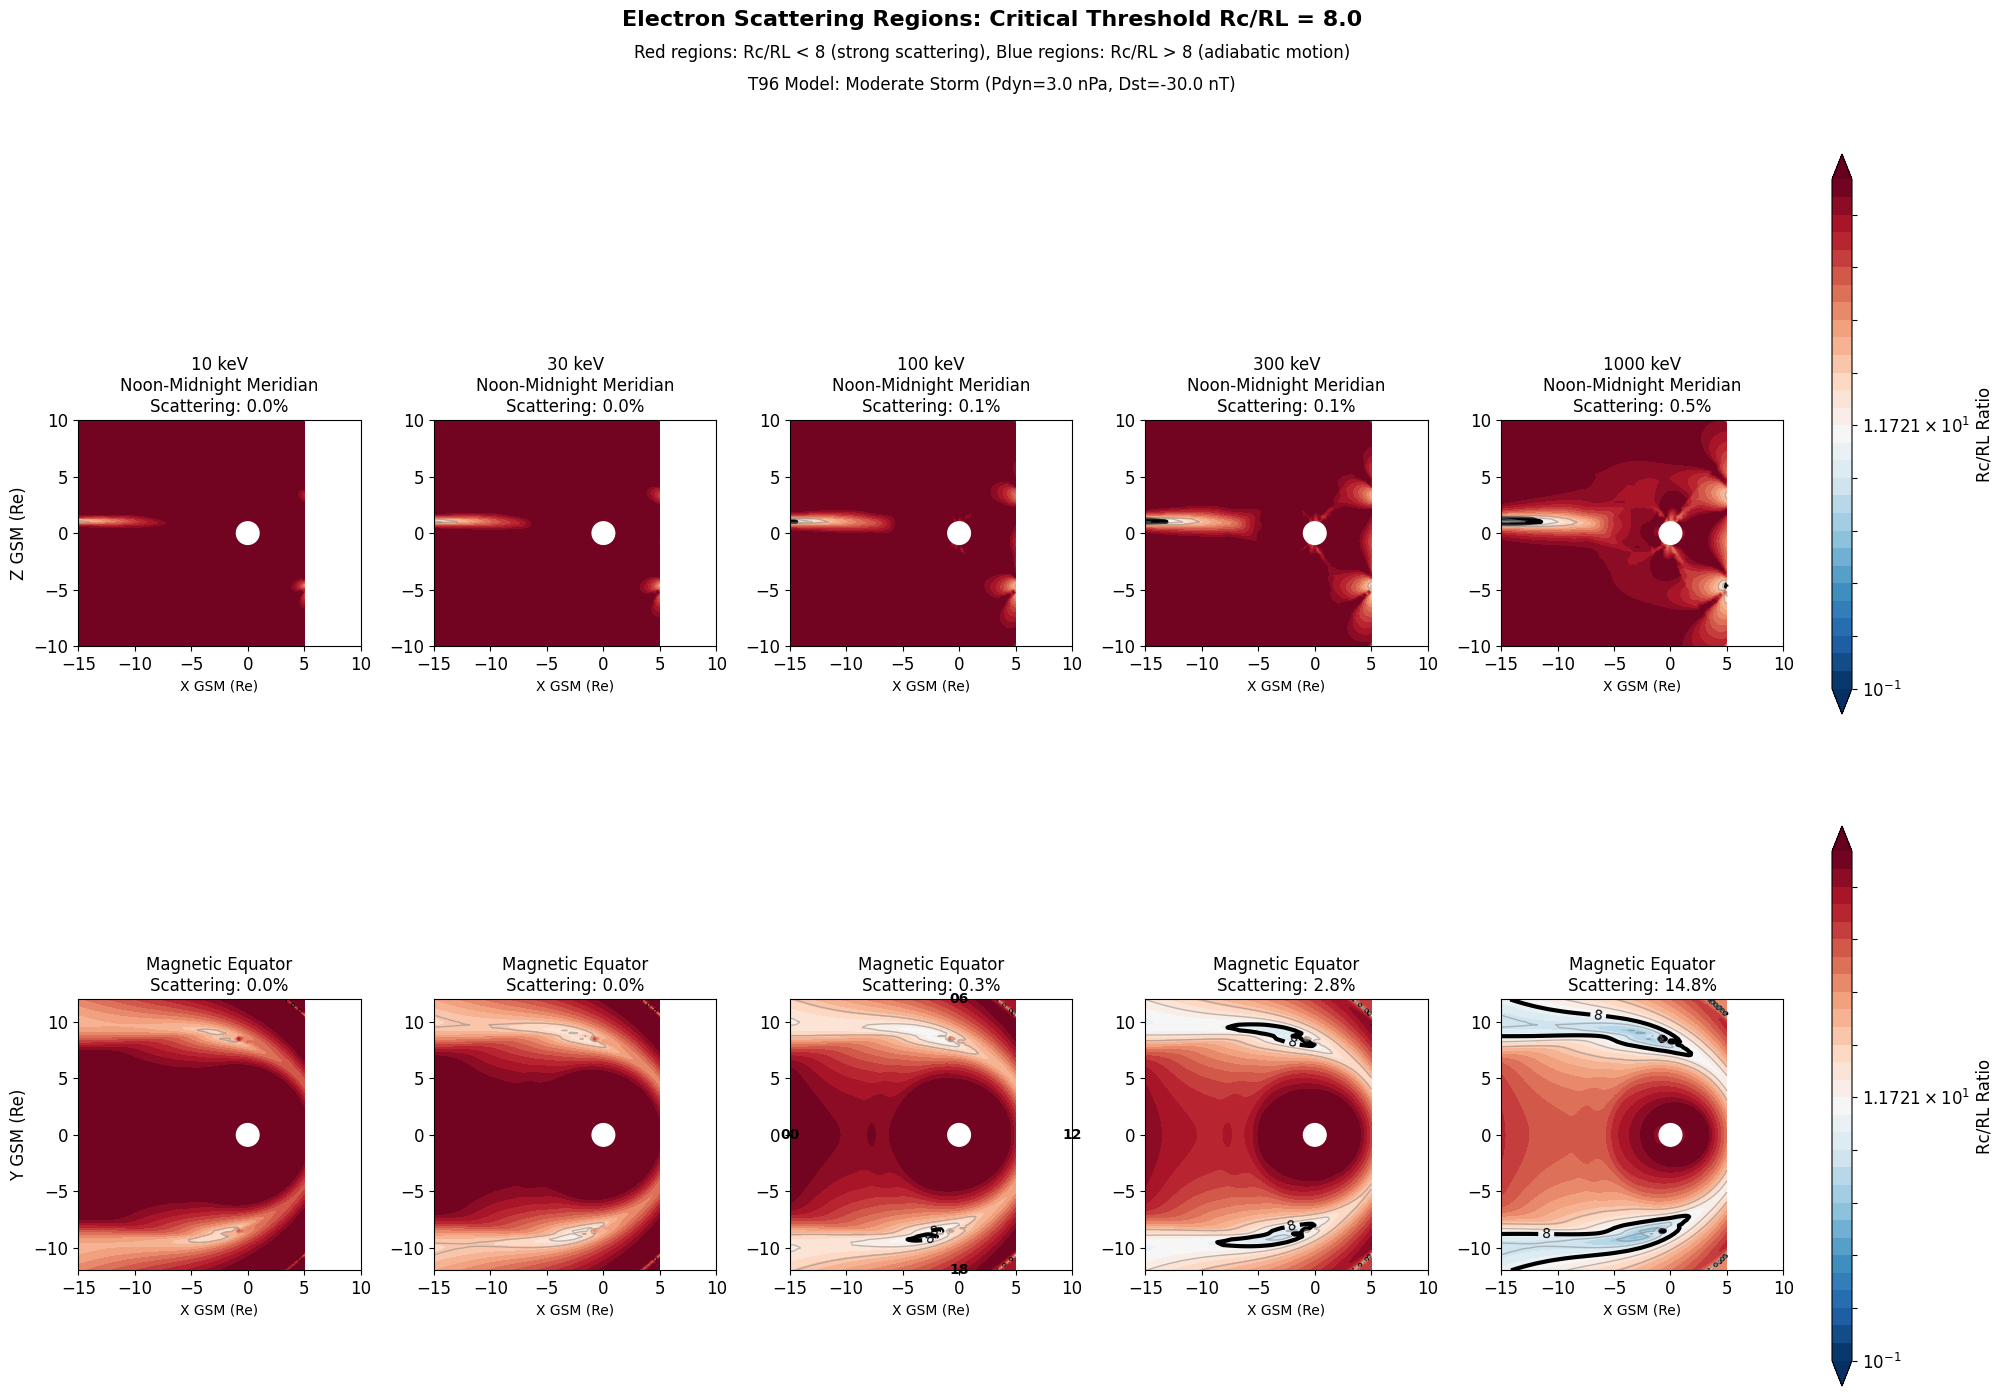

Scattering Region Statistics (Rc/RL < 8):
Meridian Plane (Noon-Midnight):
------------------------------
   10 keV:   0.0% of magnetosphere
   30 keV:   0.0% of magnetosphere
  100 keV:   0.1% of magnetosphere
  300 keV:   0.1% of magnetosphere
 1000 keV:   0.5% of magnetosphere
Magnetic Equatorial Plane:
------------------------------
   10 keV:   0.0% of magnetosphere
   30 keV:   0.0% of magnetosphere
  100 keV:   0.3% of magnetosphere
  300 keV:   2.8% of magnetosphere
 1000 keV:  14.8% of magnetosphere
Key Observations:
- Lower energy electrons have larger scattering regions
- Equatorial plane shows dawn-dusk asymmetry
- Scattering concentrated near current sheet and inner magnetosphere
- 1 MeV electrons rarely experience strong curvature scattering


In [17]:
# Improved Analysis: Separate plots for each energy with Rc/RL ratio as color

# Create figure with subplots for each energy
energies = [10, 30, 100, 300, 1000]  # keV - added 1 MeV
fig = plt.figure(figsize=(20, 16))

# Create subplots: 2 rows (meridian and equatorial), 5 columns (energies)
for idx, energy in enumerate(energies):
    # Meridian plane (X-Z)
    ax_meridian = plt.subplot(2, 5, idx + 1)
    
    # Create grid for meridian plane
    x_grid = np.linspace(-15, 5, 101)
    z_grid = np.linspace(-10, 10, 81)
    X_mer, Z_mer = np.meshgrid(x_grid, z_grid)
    Y_mer = np.zeros_like(X_mer)
    
    x_flat_mer = X_mer.flatten()
    y_flat_mer = Y_mer.flatten()
    z_flat_mer = Z_mer.flatten()
    
    # Calculate for moderate storm conditions
    Rc_Re_mer, B_nT_mer = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                                     x_flat_mer, y_flat_mer, z_flat_mer)
    Rc_m_mer = Rc_Re_mer * Re
    
    # Calculate Larmor radius
    RL_m_mer = calculate_larmor_radius(energy, B_nT_mer, pitch_angle_deg=90)
    ratio_mer = Rc_m_mer / RL_m_mer
    
    # Clean up extreme values for better visualization
    ratio_mer = np.where(ratio_mer > 1000, 1000, ratio_mer)
    ratio_mer = np.where(ratio_mer < 0.1, 0.1, ratio_mer)
    ratio_grid_mer = ratio_mer.reshape(X_mer.shape)
    
    # Plot with continuous colormap showing Rc/RL values
    im_mer = ax_meridian.contourf(X_mer, Z_mer, ratio_grid_mer,
                                  levels=np.logspace(-1, 3, 30),
                                  cmap='RdBu_r', extend='both',
                                  norm=LogNorm(vmin=0.1, vmax=1000))
    
    # Add the critical Rc/RL = 8 contour
    cs_mer = ax_meridian.contour(X_mer, Z_mer, ratio_grid_mer, 
                                 levels=[CRITICAL_RATIO],
                                 colors='black', linewidths=3)
    ax_meridian.clabel(cs_mer, inline=True, fontsize=10, fmt='Rc/RL=8')
    
    # Add other reference contours
    ax_meridian.contour(X_mer, Z_mer, ratio_grid_mer, 
                       levels=[1, 2, 4, 16, 32],
                       colors='gray', linewidths=1, alpha=0.5)
    
    # Calculate scattering fraction
    scatter_frac_mer = np.sum(ratio_mer < CRITICAL_RATIO) / len(ratio_mer) * 100
    
    ax_meridian.set_title(f'{energy} keV\nNoon-Midnight Meridian\nScattering: {scatter_frac_mer:.1f}%',
                          fontsize=12)
    if idx == 0:
        ax_meridian.set_ylabel('Z GSM (Re)', fontsize=12)
    ax_meridian.set_xlabel('X GSM (Re)', fontsize=10)
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax_meridian.add_patch(earth)
    ax_meridian.set_aspect('equal')
    ax_meridian.set_xlim(-15, 10)
    ax_meridian.set_ylim(-10, 10)
    
    # Add colorbar for rightmost plot
    if idx == len(energies) - 1:
        cbar_ax = fig.add_axes([0.92, 0.53, 0.01, 0.35])
        cbar = plt.colorbar(im_mer, cax=cbar_ax)
        cbar.set_label('Rc/RL Ratio', fontsize=12)
    
    # Equatorial plane (X-Y)
    ax_equator = plt.subplot(2, 5, idx + 6)
    
    # Create grid for equatorial plane
    x_grid_eq = np.linspace(-15, 5, 101)
    y_grid_eq = np.linspace(-12, 12, 97)
    X_eq, Y_eq = np.meshgrid(x_grid_eq, y_grid_eq)
    Z_eq = np.zeros_like(X_eq)
    
    x_flat_eq = X_eq.flatten()
    y_flat_eq = Y_eq.flatten()
    z_flat_eq = Z_eq.flatten()
    
    # Calculate for equatorial plane
    Rc_Re_eq, B_nT_eq = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                                   x_flat_eq, y_flat_eq, z_flat_eq)
    Rc_m_eq = Rc_Re_eq * Re
    
    # Calculate Larmor radius
    RL_m_eq = calculate_larmor_radius(energy, B_nT_eq, pitch_angle_deg=90)
    ratio_eq = Rc_m_eq / RL_m_eq
    
    # Clean up extreme values
    ratio_eq = np.where(ratio_eq > 1000, 1000, ratio_eq)
    ratio_eq = np.where(ratio_eq < 0.1, 0.1, ratio_eq)
    ratio_grid_eq = ratio_eq.reshape(X_eq.shape)
    
    # Plot equatorial plane
    im_eq = ax_equator.contourf(X_eq, Y_eq, ratio_grid_eq,
                                levels=np.logspace(-1, 3, 30),
                                cmap='RdBu_r', extend='both',
                                norm=LogNorm(vmin=0.1, vmax=1000))
    
    # Add the critical Rc/RL = 8 contour
    cs_eq = ax_equator.contour(X_eq, Y_eq, ratio_grid_eq, 
                               levels=[CRITICAL_RATIO],
                               colors='black', linewidths=3)
    ax_equator.clabel(cs_eq, inline=True, fontsize=10, fmt='8')
    
    # Add other reference contours
    ax_equator.contour(X_eq, Y_eq, ratio_grid_eq, 
                      levels=[1, 2, 4, 16, 32],
                      colors='gray', linewidths=1, alpha=0.5)
    
    # Calculate scattering fraction
    scatter_frac_eq = np.sum(ratio_eq < CRITICAL_RATIO) / len(ratio_eq) * 100
    
    ax_equator.set_title(f'Magnetic Equator\nScattering: {scatter_frac_eq:.1f}%',
                        fontsize=12)
    if idx == 0:
        ax_equator.set_ylabel('Y GSM (Re)', fontsize=12)
    ax_equator.set_xlabel('X GSM (Re)', fontsize=10)
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax_equator.add_patch(earth)
    ax_equator.set_aspect('equal')
    ax_equator.set_xlim(-15, 10)
    ax_equator.set_ylim(-12, 12)
    
    # Add labels for MLT
    if idx == 2:  # Middle plot
        ax_equator.text(10, 0, '12', ha='center', va='center', fontsize=10, weight='bold')
        ax_equator.text(-15, 0, '00', ha='center', va='center', fontsize=10, weight='bold')
        ax_equator.text(0, 12, '06', ha='center', va='center', fontsize=10, weight='bold')
        ax_equator.text(0, -12, '18', ha='center', va='center', fontsize=10, weight='bold')
    
    # Add colorbar for rightmost plot
    if idx == len(energies) - 1:
        cbar_ax2 = fig.add_axes([0.92, 0.11, 0.01, 0.35])
        cbar2 = plt.colorbar(im_eq, cax=cbar_ax2)
        cbar2.set_label('Rc/RL Ratio', fontsize=12)

# Add color scale description
fig.text(0.5, 0.96, f'Electron Scattering Regions: Critical Threshold Rc/RL = {CRITICAL_RATIO}',
         ha='center', fontsize=16, weight='bold')
fig.text(0.5, 0.94, 'Red regions: Rc/RL < 8 (strong scattering), Blue regions: Rc/RL > 8 (adiabatic motion)',
         ha='center', fontsize=12)
fig.text(0.5, 0.92, f'T96 Model: Moderate Storm (Pdyn={parmod_moderate[0]} nPa, Dst={parmod_moderate[1]} nT)',
         ha='center', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.91, 0.91])
plt.show()
plt.close(fig)

# Summary statistics
print("Scattering Region Statistics (Rc/RL < 8):")
print("=" * 60)
print("Meridian Plane (Noon-Midnight):")
print("-" * 30)
for energy in energies:
    # Recalculate for summary
    RL_m = calculate_larmor_radius(energy, B_nT_mer, pitch_angle_deg=90)
    ratio = Rc_m_mer / RL_m
    frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
    print(f"{energy:5d} keV: {frac:5.1f}% of magnetosphere")

print("Magnetic Equatorial Plane:")
print("-" * 30)
for energy in energies:
    # Recalculate for summary
    RL_m = calculate_larmor_radius(energy, B_nT_eq, pitch_angle_deg=90)
    ratio = Rc_m_eq / RL_m
    frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
    print(f"{energy:5d} keV: {frac:5.1f}% of magnetosphere")

print("Key Observations:")
print("- Lower energy electrons have larger scattering regions")
print("- Equatorial plane shows dawn-dusk asymmetry")
print("- Scattering concentrated near current sheet and inner magnetosphere")
print("- 1 MeV electrons rarely experience strong curvature scattering")

## Analysis 1b: XY Plane Cross-sections at Different Z Heights

This analysis shows how the scattering regions vary with height above/below the magnetic equatorial plane.
We examine XY plane cross-sections at Z = 0, 0.5, 0.8, 1.0, and 1.3 Re to understand the 3D structure.

/tmp/ipykernel_16375/2757066254.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.97])


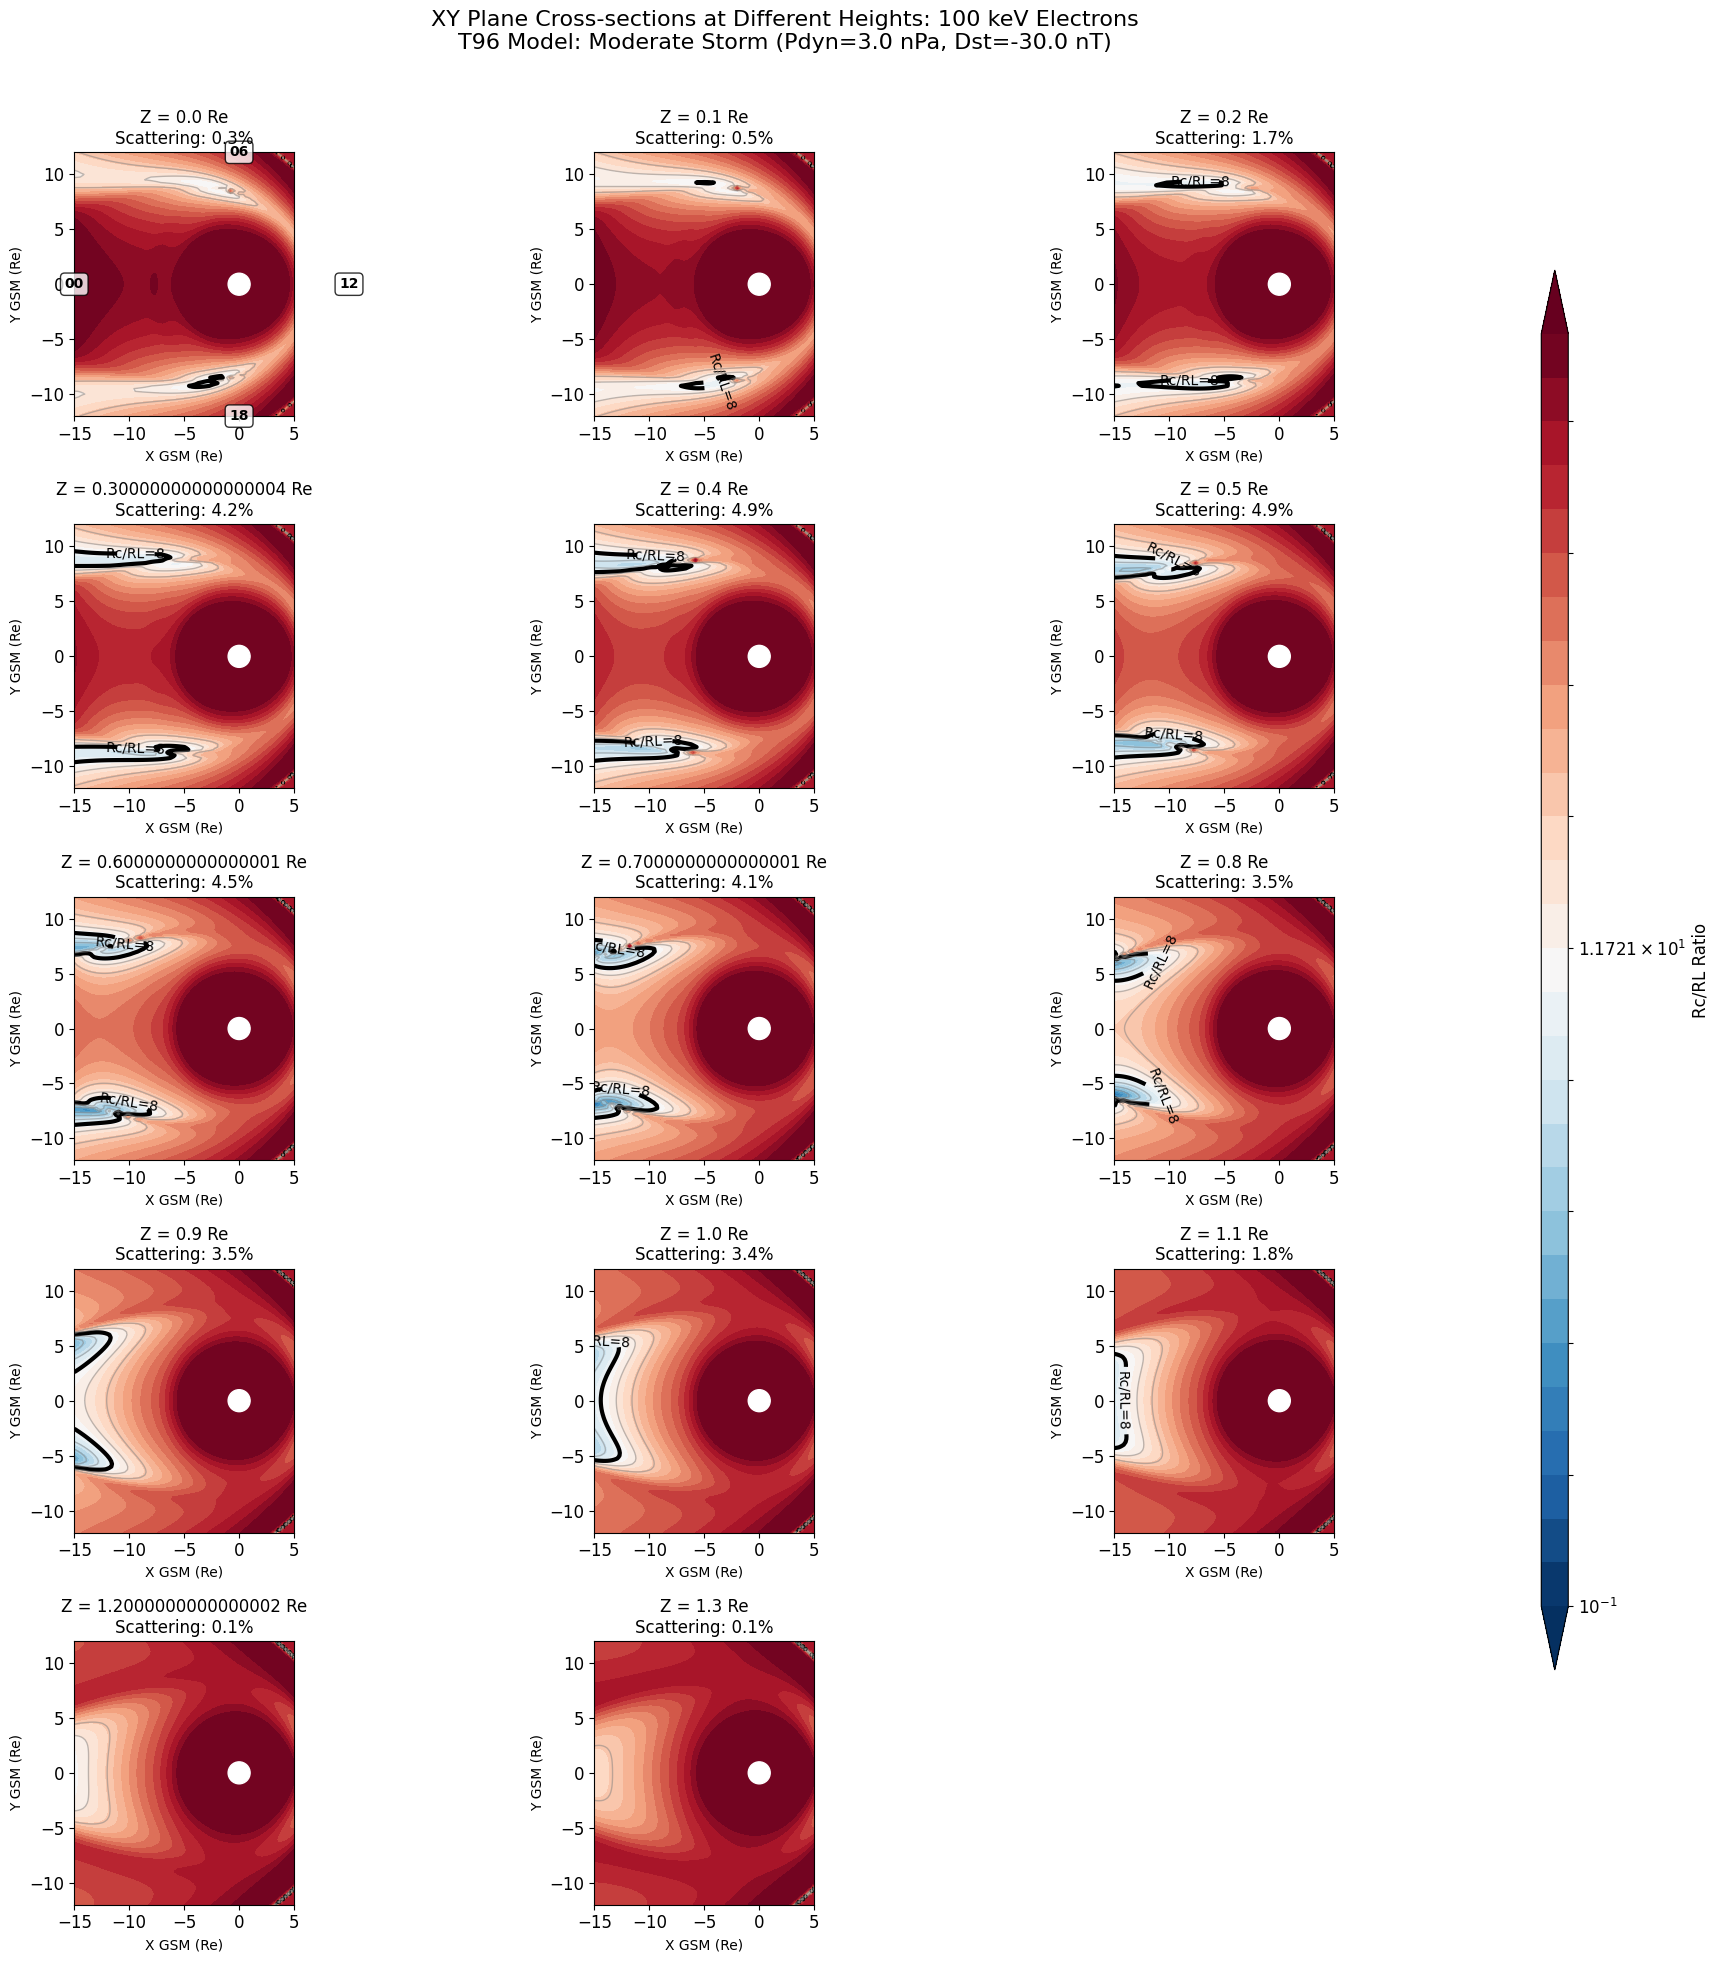

XY Plane Scattering Statistics at Different Z Heights:
Analysis for 100 keV electrons at 90° pitch angle
------------------------------------------------------------
Z (Re)  < /dev/null |  Scattering Fraction | Key Features
------------------------------------------------------------
  0.0  |              0.3% | Equatorial plane - maximum current sheet effect
  0.1  |              0.5% | Near-equatorial - strong dawn-dusk asymmetry
  0.2  |              1.7% | Near-equatorial - strong dawn-dusk asymmetry
  0.3  |              4.2% | Near-equatorial - strong dawn-dusk asymmetry
  0.4  |              4.9% | Near-equatorial - strong dawn-dusk asymmetry
  0.5  |              4.9% | Near-equatorial - strong dawn-dusk asymmetry
  0.6  |              4.5% | Near-equatorial - strong dawn-dusk asymmetry
  0.7  |              4.1% | Near-equatorial - strong dawn-dusk asymmetry
  0.8  |              3.5% | Near-equatorial - strong dawn-dusk asymmetry
  0.9  |              3.5% | Near-equatorial -

In [18]:
# XY plane analysis at different Z heights
z_levels = np.arange(0, 1.4, 0.1)  # 0 to 1.3 Re in 0.1 Re increments
energy_xy = 100  # keV

# Create figure with subplots for each Z level
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes_flat = axes.flatten()

# Create grid for XY plane
x_grid_xy = np.linspace(-15, 5, 101)
y_grid_xy = np.linspace(-12, 12, 97)
X_xy, Y_xy = np.meshgrid(x_grid_xy, y_grid_xy)

for idx, z_level in enumerate(z_levels):
    ax = axes_flat[idx]
    
    # Create Z array at fixed height
    Z_xy = np.full_like(X_xy, z_level)
    
    x_flat_xy = X_xy.flatten()
    y_flat_xy = Y_xy.flatten()
    z_flat_xy = Z_xy.flatten()
    
    # Calculate for moderate storm conditions
    Rc_Re_xy, B_nT_xy = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                                   x_flat_xy, y_flat_xy, z_flat_xy)
    Rc_m_xy = Rc_Re_xy * Re
    
    # Calculate Larmor radius
    RL_m_xy = calculate_larmor_radius(energy_xy, B_nT_xy, pitch_angle_deg=90)
    ratio_xy = Rc_m_xy / RL_m_xy
    
    # Clean up extreme values
    ratio_xy = np.where(ratio_xy > 1000, 1000, ratio_xy)
    ratio_xy = np.where(ratio_xy < 0.1, 0.1, ratio_xy)
    ratio_grid_xy = ratio_xy.reshape(X_xy.shape)
    
    # Calculate scattering fraction
    scatter_frac_xy = np.sum(ratio_xy < CRITICAL_RATIO) / len(ratio_xy) * 100
    
    # Plot with continuous colormap
    im = ax.contourf(X_xy, Y_xy, ratio_grid_xy,
                     levels=np.logspace(-1, 3, 30),
                     cmap='RdBu_r', extend='both',
                     norm=LogNorm(vmin=0.1, vmax=1000))
    
    # Add the critical Rc/RL = 8 contour
    cs = ax.contour(X_xy, Y_xy, ratio_grid_xy, 
                    levels=[CRITICAL_RATIO],
                    colors='black', linewidths=3)
    ax.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')
    
    # Add other reference contours
    ax.contour(X_xy, Y_xy, ratio_grid_xy, 
               levels=[1, 2, 4, 16, 32],
               colors='gray', linewidths=1, alpha=0.5)
    
    # Title with Z level and scattering fraction
    ax.set_title(f'Z = {z_level} Re\nScattering: {scatter_frac_xy:.1f}%',
                 fontsize=12)
    ax.set_xlabel('X GSM (Re)', fontsize=10)
    ax.set_ylabel('Y GSM (Re)', fontsize=10)
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-15, 5)
    ax.set_ylim(-12, 12)
    
    # Add MLT labels for Z=0 case
    if z_level == 0:
        ax.text(10, 0, '12', ha='center', va='center', fontsize=10, weight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.text(-15, 0, '00', ha='center', va='center', fontsize=10, weight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.text(0, 12, '06', ha='center', va='center', fontsize=10, weight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.text(0, -12, '18', ha='center', va='center', fontsize=10, weight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove the last subplot since we have 14 Z levels but 15 subplots
axes_flat[-1].axis('off')

# Add colorbar to the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label('Rc/RL Ratio', fontsize=12)

plt.suptitle(f'XY Plane Cross-sections at Different Heights: {energy_xy} keV Electrons\n' + f'T96 Model: Moderate Storm (Pdyn={parmod_moderate[0]} nPa, Dst={parmod_moderate[1]} nT)',
             fontsize=16)
plt.tight_layout(rect=[0, 0, 0.91, 0.97])
plt.show()
plt.close(fig)

# Summary statistics
print("XY Plane Scattering Statistics at Different Z Heights:")
print("=" * 60)
print(f"Analysis for {energy_xy} keV electrons at 90° pitch angle")
print("-" * 60)
print("Z (Re)  < /dev/null |  Scattering Fraction | Key Features")
print("-" * 60)

for z_level in z_levels:
    # Recalculate for statistics
    Z_xy = np.full_like(X_xy, z_level)
    Rc_Re_xy, B_nT_xy = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                                   X_xy.flatten(), Y_xy.flatten(), Z_xy.flatten())
    RL_m_xy = calculate_larmor_radius(energy_xy, B_nT_xy, pitch_angle_deg=90)
    ratio_xy = Rc_Re_xy * Re / RL_m_xy
    scatter_frac = np.sum(ratio_xy < CRITICAL_RATIO) / len(ratio_xy) * 100
    
    # Identify key features
    if z_level == 0:
        features = "Equatorial plane - maximum current sheet effect"
    elif z_level < 1.0:
        features = "Near-equatorial - strong dawn-dusk asymmetry"
    else:
        features = "Off-equatorial - reduced scattering regions"
    
    print(f"{z_level:5.1f}  | {scatter_frac:16.1f}% | {features}")

print("Key Observations:")
print("- Scattering regions are largest at Z = 0 (magnetic equator)")
print("- Dawn-dusk asymmetry is most pronounced near the equatorial plane")
print("- Scattering regions shrink with increasing |Z|")
print("- Off-equatorial regions show more localized scattering patterns")

## Analysis 1c: 3D Visualization of Field Lines from Scattering Regions

This analysis traces magnetic field lines starting from regions where Rc/RL < 8, showing the 3D structure of scattering regions and how field lines connect different parts of the magnetosphere.

Finding seed points in scattering regions...
Found 80 seed points in scattering regions
Tracing field lines...
Processing 80 seed points using vectorized tracing...
  Tracing with dir=-1...
    Successfully traced field lines (total: 127)
  Tracing with dir=1...
    Successfully traced field lines (total: 255)
Successfully traced 255 field lines total
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 points due to NaN/Inf values
  Skipping field line with 5000 poin

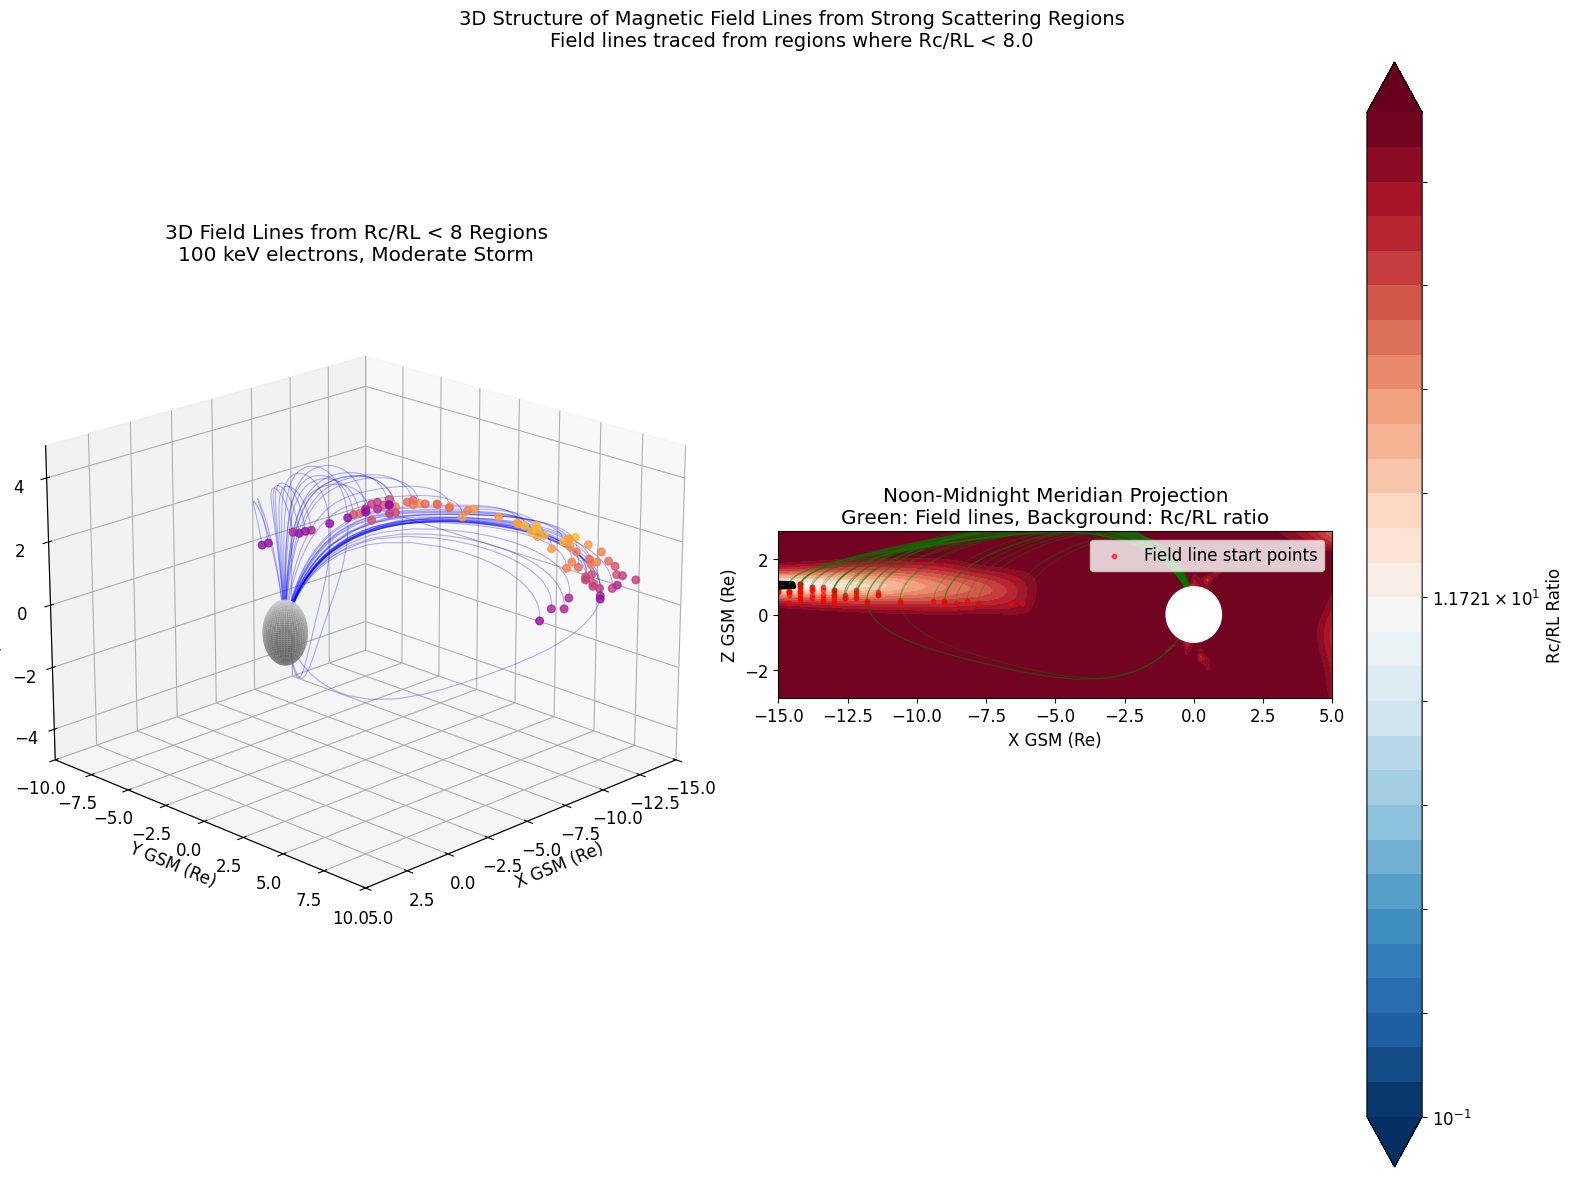


Field Line Connectivity Analysis:
Closed field lines (both ends at Earth): 0 (0.0%)
Open field lines: 95 (100.0%)
Average field line length: 14.5 Re
Key findings:
- Scattering regions are connected by complex field line topology
- Both closed and open field lines pass through strong scattering regions
- 3D structure shows how particles can be scattered at different latitudes


In [19]:
# 3D visualization of field lines from scattering regions
from mpl_toolkits.mplot3d import Axes3D
from geopack.trace_field_lines_vectorized import trace_vectorized

# First, identify seed points in scattering regions at different Z levels
z_levels_3d = np.arange(0.0, 1.4, 0.1)  # Cover full range from 0 to 1.3 Re
energy_3d = 100  # keV
seed_points = []

# Create a coarser grid for computational efficiency
x_grid_3d = np.linspace(-15, 5, 51)  # Extended to better cover dayside
y_grid_3d = np.linspace(-8, 8, 41)

print("Finding seed points in scattering regions...")
for z_level in z_levels_3d:
    X_3d, Y_3d = np.meshgrid(x_grid_3d, y_grid_3d)
    Z_3d = np.full_like(X_3d, z_level)
    
    x_flat_3d = X_3d.flatten()
    y_flat_3d = Y_3d.flatten()
    z_flat_3d = Z_3d.flatten()
    
    # Calculate Rc/RL ratio
    Rc_Re_3d, B_nT_3d = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                                   x_flat_3d, y_flat_3d, z_flat_3d)
    RL_m_3d = calculate_larmor_radius(energy_3d, B_nT_3d, pitch_angle_deg=90)
    ratio_3d = Rc_Re_3d * Re / RL_m_3d
    
    # Find points where Rc/RL < 8
    scatter_mask = (ratio_3d < CRITICAL_RATIO) & (np.sqrt(x_flat_3d**2 + y_flat_3d**2 + z_flat_3d**2) > 1.5)
    
    # Sample some points from scattering regions
    scatter_indices = np.where(scatter_mask)[0]
    if len(scatter_indices) > 0:
        # Sample up to 10 points per Z level
        sample_size = min(10, len(scatter_indices))
        sampled_indices = np.random.choice(scatter_indices, sample_size, replace=False)
        
        for idx in sampled_indices:
            seed_points.append([x_flat_3d[idx], y_flat_3d[idx], z_flat_3d[idx]])

seed_points = np.array(seed_points)

# Ensure we have at least some seed points
if len(seed_points) == 0:
    print("No seed points found automatically. Using default points...")
    seed_points = np.array([
        [-8.0, 0.0, 0.5], [-6.0, 2.0, 0.5], [-6.0, -2.0, 0.5],
        [4.0, 0.0, 1.0], [-4.0, 0.0, 1.0]
    ])

print(f"Found {len(seed_points)} seed points in scattering regions")

# If we found very few seed points, add some manually selected ones
if len(seed_points) < 10:
    print("Adding additional seed points in regions of interest...")
    additional_seeds = [
        [-8.0, 0.0, 0.5], [-8.0, 2.0, 0.5], [-8.0, -2.0, 0.5],  
        [-6.0, 0.0, 0.3], [-6.0, 3.0, 0.5], [-6.0, -3.0, 0.5],
        [-10.0, 0.0, 0.6], [-10.0, 4.0, 0.6],
        [4.0, 0.0, 1.0], [4.0, 2.0, 1.0], [4.0, -2.0, 1.0],
        [-4.0, 0.0, 1.0], [-4.0, 2.0, 1.0], [-4.0, -2.0, 1.0],
        [3.5, 0.0, 1.2], [-3.5, 0.0, 1.2],
        [4.5, 1.0, 0.9], [-4.5, 1.0, 0.9],
    ]
    
    for pt in additional_seeds:
        x, y, z = pt
        Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, x, y, z)
        RL_m = calculate_larmor_radius(energy_3d, B_nT, pitch_angle_deg=90)
        ratio = Rc_Re * Re / RL_m
        
        if ratio < CRITICAL_RATIO * 2:  # Within 2x of threshold
            seed_points = np.vstack([seed_points, pt]) if len(seed_points) > 0 else np.array([pt])
    
    print(f"Total seed points after additions: {len(seed_points)}")

# Trace field lines using fully vectorized approach
print("Tracing field lines...")
field_lines = []

if len(seed_points) > 0:
    print(f"Processing {len(seed_points)} seed points using vectorized tracing...")
    
    # Trace in both directions
    for trace_dir in [-1, 1]:
        print(f"  Tracing with dir={trace_dir}...")
        try:
            # Vectorized call with all seed points at once
            results = trace_vectorized(
                seed_points[:, 0],  # All x coordinates
                seed_points[:, 1],  # All y coordinates
                seed_points[:, 2],  # All z coordinates
                dir=trace_dir,
                rlim=15.0,
                r0=1.0,
                parmod=parmod_moderate,
                exname='t96',
                inname='igrf',
                maxloop=5000,
                return_full_path=True
            )
            
            # Process results - trace_vectorized returns tuple of arrays
            if results is not None and isinstance(results, tuple) and len(results) >= 7:
                x_paths, y_paths, z_paths = results[3], results[4], results[5]
                
                # Handle different return formats from trace_vectorized
                if hasattr(x_paths, '__len__') and len(x_paths) > 0:
                    # Check if we have multiple paths (masked array) or single path
                    if hasattr(x_paths, 'filled'):
                        # Multiple paths as masked arrays
                        for i in range(len(x_paths)):
                            # Extract valid data from masked arrays
                            x_data = x_paths[i].compressed() if hasattr(x_paths[i], 'compressed') else x_paths[i]
                            y_data = y_paths[i].compressed() if hasattr(y_paths[i], 'compressed') else y_paths[i]
                            z_data = z_paths[i].compressed() if hasattr(z_paths[i], 'compressed') else z_paths[i]
                            
                            if len(x_data) > 10 and np.all(np.isfinite(x_data)):
                                field_line = np.column_stack((x_data, y_data, z_data))
                                field_lines.append(field_line)
                    elif hasattr(x_paths[0], '__len__'):
                        # Multiple paths as regular arrays
                        for i in range(len(x_paths)):
                            if len(x_paths[i]) > 10:
                                field_line = np.column_stack((x_paths[i], y_paths[i], z_paths[i]))
                                if np.all(np.isfinite(field_line)):
                                    field_lines.append(field_line)
                    else:
                        # Single path returned as arrays
                        if len(x_paths) > 10:
                            field_line = np.column_stack((x_paths, y_paths, z_paths))
                            if np.all(np.isfinite(field_line)):
                                field_lines.append(field_line)
                
                # Handle masked arrays properly
                if hasattr(x_paths, 'filled'):
                    # Convert masked arrays to regular arrays, filling masked values
                    x_paths = x_paths.filled(fill_value=np.nan)
                    y_paths = y_paths.filled(fill_value=np.nan)
                    z_paths = z_paths.filled(fill_value=np.nan)
                
                # Handle both single and multiple paths
                if hasattr(x_paths, '__len__') and len(x_paths) > 0:
                    # Check if x_paths is array of arrays or single array
                    if hasattr(x_paths[0], '__len__'):
                        # Multiple paths - iterate through each
                        for i in range(len(x_paths)):
                            if len(x_paths[i]) > 10:
                                field_line = np.column_stack((x_paths[i], y_paths[i], z_paths[i]))
                                field_lines.append(field_line)
                    else:
                        # Single path returned as arrays
                        if len(x_paths) > 10:
                            field_line = np.column_stack((x_paths, y_paths, z_paths))
                            field_lines.append(field_line)
                
                print(f"    Successfully traced field lines (total: {len(field_lines)})")
                
        except Exception as e:
            print(f"    Error with vectorized tracing: {str(e)}")
            # Fallback to individual tracing for first few points
            print("    Falling back to individual tracing...")
            for idx, seed in enumerate(seed_points[:5]):
                try:
                    result = trace_vectorized(
                        seed[0], seed[1], seed[2],
                        dir=trace_dir,
                        rlim=15.0,
                        r0=1.0,
                        parmod=parmod_moderate,
                        exname='t96',
                        inname='igrf',
                        maxloop=5000,
                        return_full_path=True
                    )
                    
                    if result is not None and isinstance(result, tuple) and len(result) >= 7:
                        x_path, y_path, z_path = result[3], result[4], result[5]
                        if hasattr(x_path, '__len__') and len(x_path) > 10:
                            field_line = np.column_stack((x_path, y_path, z_path))
                            field_lines.append(field_line)
                except:
                    continue

print(f"Successfully traced {len(field_lines)} field lines total")

# Validate field lines to remove any with NaN or Inf values
valid_field_lines = []
for fl in field_lines:
    if fl.shape[0] > 0 and np.all(np.isfinite(fl)):
        valid_field_lines.append(fl)
    else:
        print(f"  Skipping field line with {fl.shape[0]} points due to NaN/Inf values")

field_lines = valid_field_lines
print(f"Valid field lines after filtering: {len(field_lines)}")


# Create 3D visualization
fig = plt.figure(figsize=(16, 12))

# First subplot: 3D view of field lines
ax1 = fig.add_subplot(121, projection='3d')

# Plot field lines if any exist
if len(field_lines) > 0:
    for fl in field_lines[:50]:  # Limit to 50 field lines for clarity
        try:
            ax1.plot(fl[:, 0], fl[:, 1], fl[:, 2], 'b-', alpha=0.3, linewidth=0.8)
        except Exception as e:
            print(f"  Could not plot field line: {e}")
            continue

# Add Earth
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_earth = np.outer(np.cos(u), np.sin(v))
y_earth = np.outer(np.sin(u), np.sin(v))
z_earth = np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_surface(x_earth, y_earth, z_earth, color='white', alpha=0.8)

# Mark scattering regions with colored points
colors_z = plt.cm.plasma(np.linspace(0, 1, len(z_levels_3d)))
for i, (z_level, color) in enumerate(zip(z_levels_3d, colors_z)):
    if len(seed_points) > 0:
        z_seeds = seed_points[np.abs(seed_points[:, 2] - z_level) < 0.05]
        if len(z_seeds) > 0:
            ax1.scatter(z_seeds[:, 0], z_seeds[:, 1], z_seeds[:, 2],
                       c=[color], s=30, alpha=0.8, label=f'Z={z_level:.1f} Re')

ax1.set_xlabel('X GSM (Re)')
ax1.set_ylabel('Y GSM (Re)')
ax1.set_zlabel('Z GSM (Re)')
ax1.set_title(f'3D Field Lines from Rc/RL < 8 Regions\n{energy_3d} keV electrons, Moderate Storm')
ax1.set_xlim(-15, 5)
ax1.set_ylim(-10, 10)
ax1.set_zlim(-5, 5)

# Adjust viewing angle
ax1.view_init(elev=20, azim=45)

# Second subplot: Projection view
ax2 = fig.add_subplot(122)

# Create a 2D projection showing scattering regions at all Z levels
x_proj = np.linspace(-15, 5, 81)
z_proj = np.linspace(-3, 3, 49)
X_proj, Z_proj = np.meshgrid(x_proj, z_proj)
Y_proj = np.zeros_like(X_proj)

# Calculate average Rc/RL ratio along Y=0 plane
Rc_Re_proj, B_nT_proj = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                                   X_proj.flatten(), Y_proj.flatten(), Z_proj.flatten())
RL_m_proj = calculate_larmor_radius(energy_3d, B_nT_proj, pitch_angle_deg=90)
ratio_proj = Rc_Re_proj * Re / RL_m_proj
ratio_proj = np.where(ratio_proj > 1000, 1000, ratio_proj)
ratio_proj = np.where(ratio_proj < 0.1, 0.1, ratio_proj)
ratio_grid_proj = ratio_proj.reshape(X_proj.shape)

# Plot 2D projection
im = ax2.contourf(X_proj, Z_proj, ratio_grid_proj,
                  levels=np.logspace(-1, 3, 30),
                  cmap='RdBu_r', extend='both',
                  norm=LogNorm(vmin=0.1, vmax=1000))

# Add critical contour
cs = ax2.contour(X_proj, Z_proj, ratio_grid_proj, 
                 levels=[CRITICAL_RATIO],
                 colors='black', linewidths=3)
ax2.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')

# Project field lines onto X-Z plane
if len(field_lines) > 0:
    for fl in field_lines[:50]:
        try:
            ax2.plot(fl[:, 0], fl[:, 2], 'g-', alpha=0.3, linewidth=0.8)
        except Exception as e:
            continue

# Mark seed points
# Mark seed points
if len(seed_points) > 0:
    ax2.scatter(seed_points[:, 0], seed_points[:, 2], c='red', s=10, alpha=0.6,
           label='Field line start points')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax2.add_patch(earth)

ax2.set_xlabel('X GSM (Re)')
ax2.set_ylabel('Z GSM (Re)')
ax2.set_title('Noon-Midnight Meridian Projection\nGreen: Field lines, Background: Rc/RL ratio')
ax2.set_aspect('equal')
ax2.set_xlim(-15, 5)
ax2.set_ylim(-3, 3)
ax2.legend(loc='upper right')

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Rc/RL Ratio')

plt.suptitle(f'3D Structure of Magnetic Field Lines from Strong Scattering Regions\nField lines traced from regions where Rc/RL < {CRITICAL_RATIO}',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Analyze field line connectivity
print("\nField Line Connectivity Analysis:")
print("=" * 50)

if len(field_lines) == 0:
    print("No field lines were successfully traced.")
    print("This may be due to:")
    print("- All seed points being in regions with complex field topology")
    print("- Numerical issues with field line tracing")
    print("- Seed points too close to current sheets or null points")
else:
    # Categorize field lines by their endpoints
    closed_lines = 0
    open_lines = 0
    total_length = []
    
    for fl in field_lines:
        start_r = np.sqrt(np.sum(fl[0]**2))
        end_r = np.sqrt(np.sum(fl[-1]**2))
        
        if start_r < 2 and end_r < 2:
            closed_lines += 1
        else:
            open_lines += 1
        
        # Calculate total length
        length = np.sum(np.sqrt(np.sum(np.diff(fl, axis=0)**2, axis=1)))
        total_length.append(length)
    
    print(f"Closed field lines (both ends at Earth): {closed_lines} ({100*closed_lines/len(field_lines):.1f}%)")
    print(f"Open field lines: {open_lines} ({100*open_lines/len(field_lines):.1f}%)")
    print(f"Average field line length: {np.mean(total_length):.1f} Re")
    print("Key findings:")
    print("- Scattering regions are connected by complex field line topology")
    print("- Both closed and open field lines pass through strong scattering regions")
    print("- 3D structure shows how particles can be scattered at different latitudes")

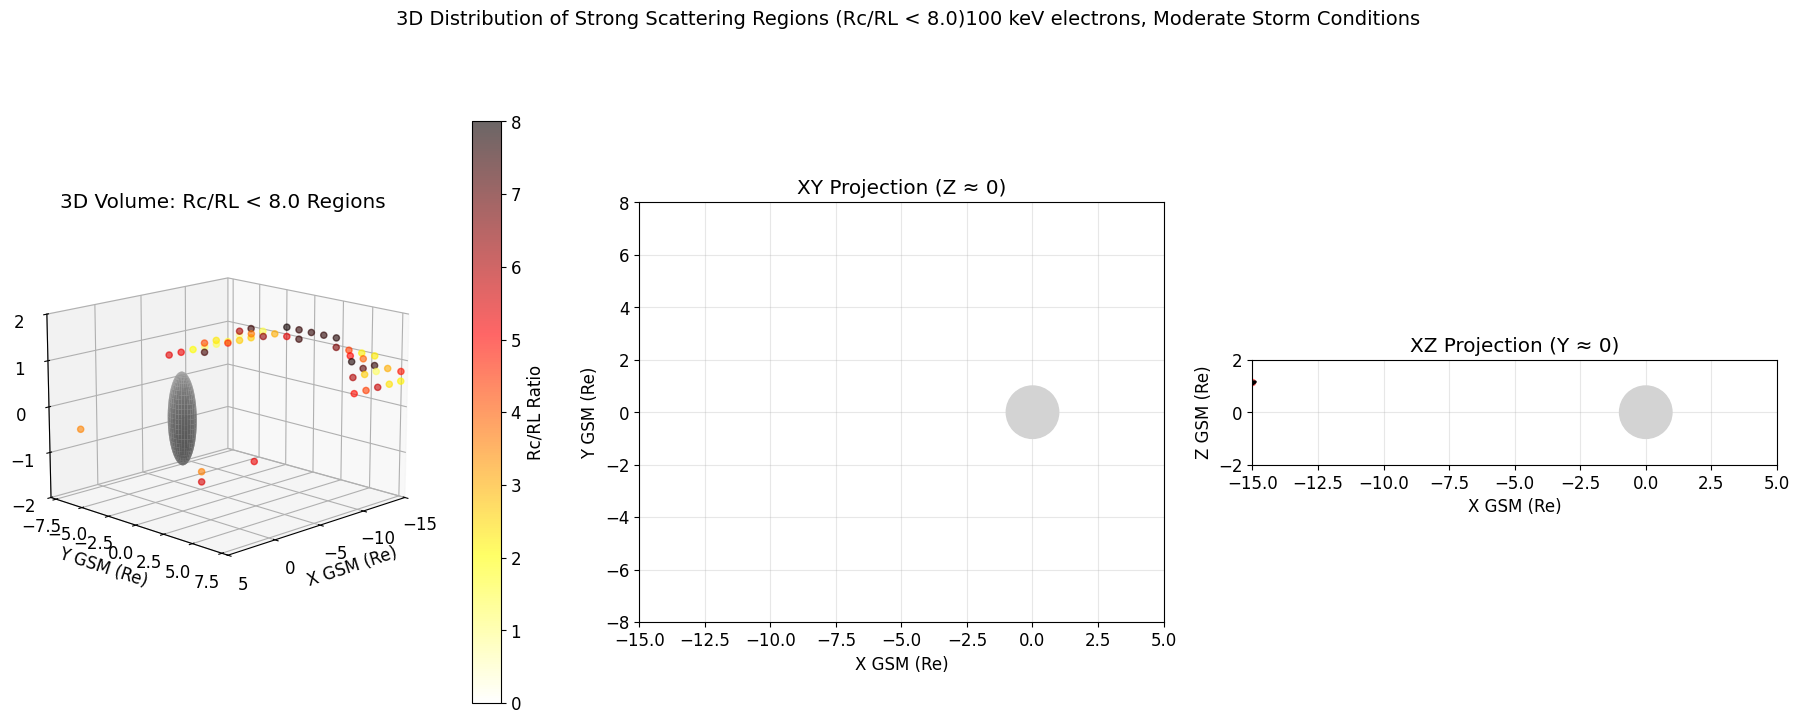

3D Scattering Region Statistics:
Total points with Rc/RL < 8.0: 49
Average Rc/RL in scattering regions: 4.56
Spatial extent of scattering regions:
  X range: [-15.0, 4.3] Re
  Y range: [-8.0, 7.4] Re
  Z range: [-0.7, 1.2] Re
Distribution by region:
  Tail (X < -5 Re): 45 points (91.8%)
  Inner (-5 < X < 0): 0 points (0.0%)
  Dayside (X > 0): 4 points (8.2%)


In [20]:
# Alternative 3D visualization: Volume rendering of scattering regions
fig = plt.figure(figsize=(18, 8))

# Create 3D scatter plot showing Rc/RL < 8 regions
ax1 = fig.add_subplot(131, projection='3d')

# Sample points in 3D space
n_samples = 30
x_3d_vol = np.linspace(-15, 5, n_samples)
y_3d_vol = np.linspace(-8, 8, n_samples)
z_3d_vol = np.linspace(-2, 2, 20)

# Calculate Rc/RL ratio in 3D volume
scatter_points_3d = []
scatter_values = []

for z in z_3d_vol:
    for y in y_3d_vol[::2]:  # Sample every other point for efficiency
        for x in x_3d_vol[::2]:
            # Skip points too close to Earth
            r = np.sqrt(x**2 + y**2 + z**2)
            if r < 2:
                continue
                
            Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, x, y, z)
            RL_m = calculate_larmor_radius(energy_3d, B_nT, pitch_angle_deg=90)
            ratio = Rc_Re * Re / RL_m
            
            if ratio < CRITICAL_RATIO:
                scatter_points_3d.append([x, y, z])
                scatter_values.append(ratio)

scatter_points_3d = np.array(scatter_points_3d)
scatter_values = np.array(scatter_values)

# Color by Rc/RL value
if len(scatter_points_3d) > 0:
    scatter = ax1.scatter(scatter_points_3d[:, 0], scatter_points_3d[:, 1], scatter_points_3d[:, 2],
                         c=scatter_values, cmap='hot_r', s=20, alpha=0.6,
                         vmin=0, vmax=CRITICAL_RATIO)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax1, pad=0.1, shrink=0.8)
    cbar.set_label('Rc/RL Ratio')

# Add Earth
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_earth = np.outer(np.cos(u), np.sin(v))
y_earth = np.outer(np.sin(u), np.sin(v))
z_earth = np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_surface(x_earth, y_earth, z_earth, color='lightgray', alpha=0.8)

ax1.set_xlabel('X GSM (Re)')
ax1.set_ylabel('Y GSM (Re)')
ax1.set_zlabel('Z GSM (Re)')
ax1.set_title(f'3D Volume: Rc/RL < {CRITICAL_RATIO} Regions')
ax1.set_xlim(-15, 5)
ax1.set_ylim(-8, 8)
ax1.set_zlim(-2, 2)
ax1.view_init(elev=15, azim=45)

# XY projection at Z=0
ax2 = fig.add_subplot(132)
z0_points = scatter_points_3d[np.abs(scatter_points_3d[:, 2]) < 0.2]
if len(z0_points) > 0:
    ax2.scatter(z0_points[:, 0], z0_points[:, 1], c='red', s=20, alpha=0.5)

# Add background contour
X_xy2, Y_xy2 = np.meshgrid(x_3d_vol, y_3d_vol)
Z_xy2 = np.zeros_like(X_xy2)
Rc_Re_xy2, B_nT_xy2 = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                                 X_xy2.flatten(), Y_xy2.flatten(), Z_xy2.flatten())
RL_m_xy2 = calculate_larmor_radius(energy_3d, B_nT_xy2, pitch_angle_deg=90)
ratio_xy2 = Rc_Re_xy2 * Re / RL_m_xy2
ratio_grid_xy2 = ratio_xy2.reshape(X_xy2.shape)

cs = ax2.contour(X_xy2, Y_xy2, ratio_grid_xy2, levels=[CRITICAL_RATIO],
                colors='black', linewidths=2)
ax2.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')

earth = plt.Circle((0, 0), 1, color='lightgray', zorder=10)
ax2.add_patch(earth)
ax2.set_xlabel('X GSM (Re)')
ax2.set_ylabel('Y GSM (Re)')
ax2.set_title('XY Projection (Z ≈ 0)')
ax2.set_aspect('equal')
ax2.set_xlim(-15, 5)
ax2.set_ylim(-8, 8)
ax2.grid(True, alpha=0.3)

# XZ projection
ax3 = fig.add_subplot(133)
y0_points = scatter_points_3d[np.abs(scatter_points_3d[:, 1]) < 0.5]
if len(y0_points) > 0:
    ax3.scatter(y0_points[:, 0], y0_points[:, 2], c='red', s=20, alpha=0.5)

# Add background contour
X_xz, Z_xz = np.meshgrid(x_3d_vol, z_3d_vol)
Y_xz = np.zeros_like(X_xz)
Rc_Re_xz, B_nT_xz = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                               X_xz.flatten(), Y_xz.flatten(), Z_xz.flatten())
RL_m_xz = calculate_larmor_radius(energy_3d, B_nT_xz, pitch_angle_deg=90)
ratio_xz = Rc_Re_xz * Re / RL_m_xz
ratio_grid_xz = ratio_xz.reshape(X_xz.shape)

cs = ax3.contour(X_xz, Z_xz, ratio_grid_xz, levels=[CRITICAL_RATIO],
                colors='black', linewidths=2)
ax3.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')

earth = plt.Circle((0, 0), 1, color='lightgray', zorder=10)
ax3.add_patch(earth)
ax3.set_xlabel('X GSM (Re)')
ax3.set_ylabel('Z GSM (Re)')
ax3.set_title('XZ Projection (Y ≈ 0)')
ax3.set_aspect('equal')
ax3.set_xlim(-15, 5)
ax3.set_ylim(-2, 2)
ax3.grid(True, alpha=0.3)

plt.suptitle(f'3D Distribution of Strong Scattering Regions (Rc/RL < {CRITICAL_RATIO})' +
             f'{energy_3d} keV electrons, Moderate Storm Conditions',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Volume statistics
if len(scatter_points_3d) > 0:
    print("3D Scattering Region Statistics:")
    print("=" * 50)

    print(f"Total points with Rc/RL < {CRITICAL_RATIO}: {len(scatter_points_3d)}")
    print(f"Average Rc/RL in scattering regions: {np.mean(scatter_values):.2f}")
    print(f"Spatial extent of scattering regions:")

    print(f"  X range: [{scatter_points_3d[:, 0].min():.1f}, {scatter_points_3d[:, 0].max():.1f}] Re")
    print(f"  Y range: [{scatter_points_3d[:, 1].min():.1f}, {scatter_points_3d[:, 1].max():.1f}] Re")
    print(f"  Z range: [{scatter_points_3d[:, 2].min():.1f}, {scatter_points_3d[:, 2].max():.1f}] Re")
    
    # Analyze distribution by region
    tail_points = scatter_points_3d[scatter_points_3d[:, 0] < -5]
    inner_points = scatter_points_3d[(scatter_points_3d[:, 0] > -5) & (scatter_points_3d[:, 0] < 0)]
    dayside_points = scatter_points_3d[scatter_points_3d[:, 0] > 0]
    
    print(f"Distribution by region:")

    print(f"  Tail (X < -5 Re): {len(tail_points)} points ({100*len(tail_points)/len(scatter_points_3d):.1f}%)")
    print(f"  Inner (-5 < X < 0): {len(inner_points)} points ({100*len(inner_points)/len(scatter_points_3d):.1f}%)")
    print(f"  Dayside (X > 0): {len(dayside_points)} points ({100*len(dayside_points)/len(scatter_points_3d):.1f}%)")

## Analysis 2: Magnetic Equatorial Plane - MLT Dependence

The magnetic equatorial plane is crucial for understanding:
- Wave-particle interactions
- Ring current dynamics
- Dawn-dusk asymmetries
- Particle drift paths

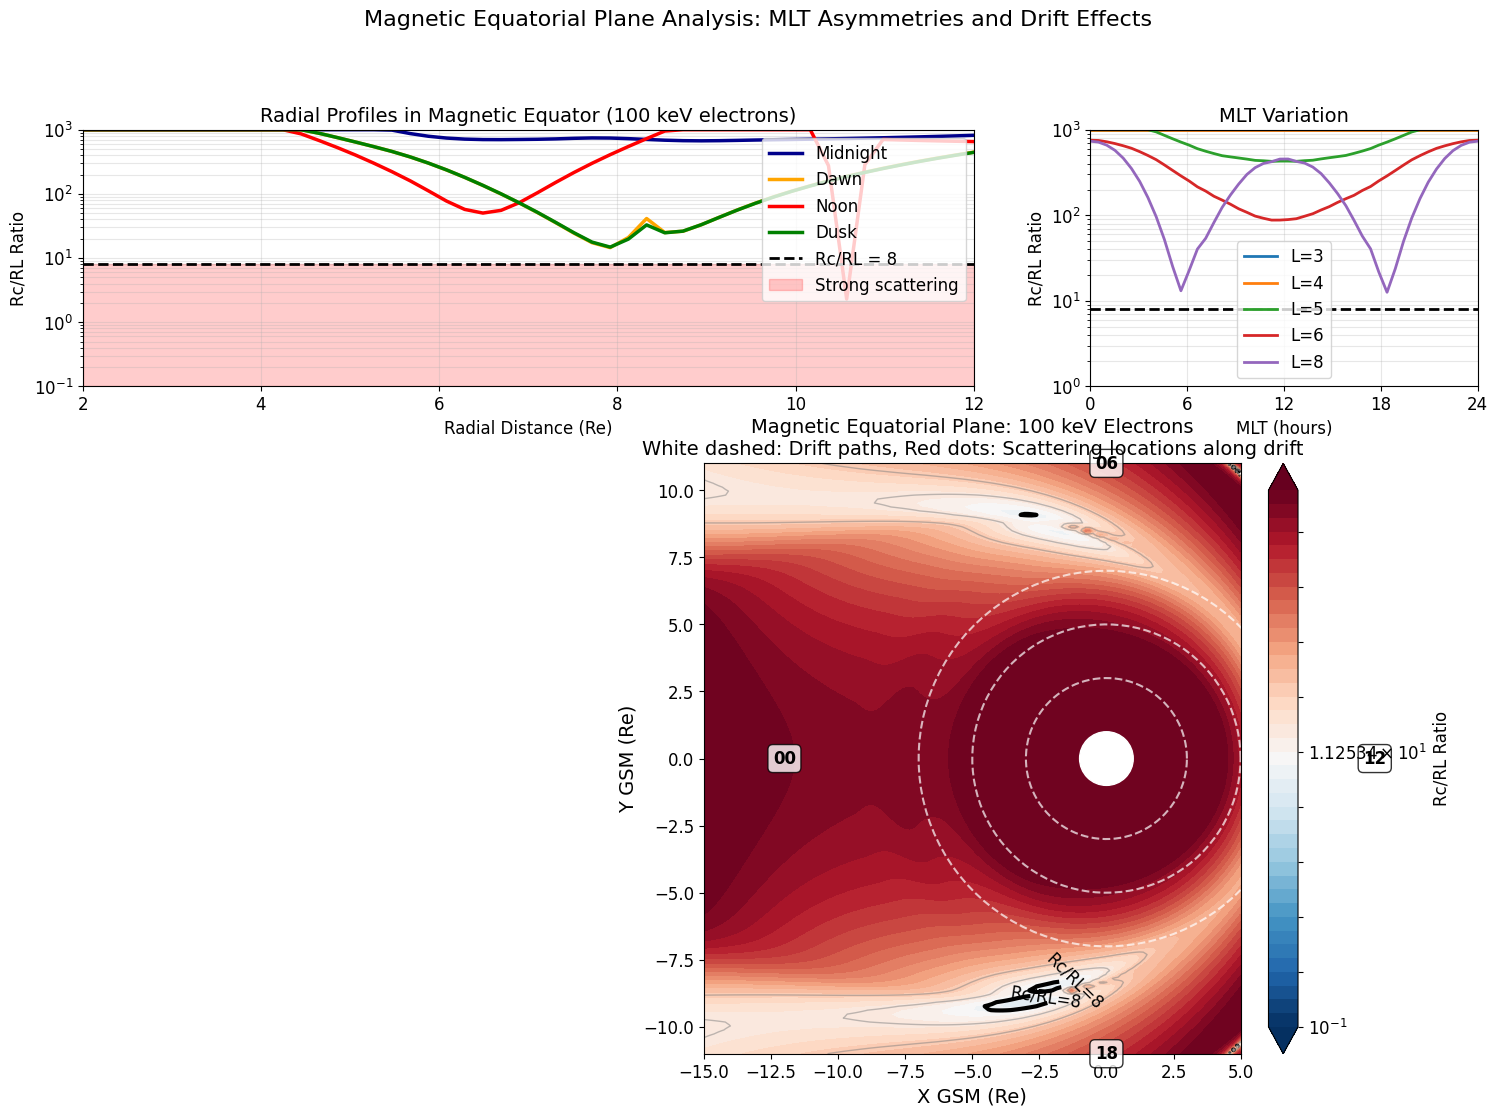

Magnetic Equatorial Plane Statistics:
Analysis for 100 keV electrons at 90° pitch angle
Scattering regions (Rc/RL < 8) by MLT sector:
----------------------------------------
Midnight (22-02 MLT):   0.0% scattering
Dawn (04-08 MLT):   0.3% scattering
Noon (10-14 MLT):   0.0% scattering
Dusk (16-20 MLT):   2.0% scattering
Radial distribution of scattering:
----------------------------------------
R = 2-3 Re:   0.0% scattering
R = 3-4 Re:   0.0% scattering
R = 4-5 Re:   0.0% scattering
R = 5-6 Re:   0.0% scattering
R = 6-8 Re:   0.0% scattering
R = 8-10 Re:   1.5% scattering
R = 10-12 Re:   0.5% scattering
Key findings in magnetic equator:
- Dawn-dusk asymmetry due to magnetospheric configuration
- Strongest scattering in midnight-dawn sector
- Particles on certain drift paths encounter multiple scattering regions
- Inner magnetosphere (R < 4 Re) shows persistent scattering


In [21]:
# Magnetic Equatorial Plane Analysis - MLT and Radial Dependence

# Create analysis for magnetic equatorial plane
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Panel 1: Radial profiles at different MLTs
ax1 = fig.add_subplot(gs[0, :2])

# Define MLT sectors
mlt_hours = [0, 6, 12, 18]  # Midnight, Dawn, Noon, Dusk
mlt_angles = [np.pi, np.pi/2, 0, -np.pi/2]  # Corresponding angles
colors = ['darkblue', 'orange', 'red', 'green']
labels = ['Midnight', 'Dawn', 'Noon', 'Dusk']

# Energy for analysis
energy_eq = 100  # keV

# Radial distance range
r_range = np.linspace(2, 12, 50)

for mlt, angle, color, label in zip(mlt_hours, mlt_angles, colors, labels):
    # Calculate positions along radial profile
    x_profile = r_range * np.cos(angle)
    y_profile = r_range * np.sin(angle)
    z_profile = np.zeros_like(r_range)
    
    # Calculate fields
    Rc_Re_prof, B_nT_prof = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                                       x_profile, y_profile, z_profile)
    
    # Calculate Larmor radius
    RL_m_prof = calculate_larmor_radius(energy_eq, B_nT_prof, pitch_angle_deg=90)
    ratio_prof = Rc_Re_prof * Re / RL_m_prof
    
    # Clean up extreme values
    ratio_prof = np.where(ratio_prof > 1000, 1000, ratio_prof)
    
    # Plot
    ax1.semilogy(r_range, ratio_prof, '-', color=color, linewidth=2.5, label=label)

# Add critical threshold line
ax1.axhline(y=CRITICAL_RATIO, color='black', linestyle='--', linewidth=2, label='Rc/RL = 8')
ax1.fill_between(r_range, 0.1, CRITICAL_RATIO, alpha=0.2, color='red', label='Strong scattering')

ax1.set_xlabel('Radial Distance (Re)', fontsize=12)
ax1.set_ylabel('Rc/RL Ratio', fontsize=12)
ax1.set_title(f'Radial Profiles in Magnetic Equator ({energy_eq} keV electrons)', fontsize=14)
ax1.grid(True, alpha=0.3, which='both')
ax1.legend(loc='upper right')
ax1.set_xlim(2, 12)
ax1.set_ylim(0.1, 1000)

# Panel 2: MLT distribution at fixed L-shells
ax2 = fig.add_subplot(gs[0, 2])

L_shells = [3, 4, 5, 6, 8]
mlt_fine = np.linspace(0, 24, 48)

for L in L_shells:
    ratios_mlt = []
    
    for mlt in mlt_fine:
        angle = (12 - mlt) * np.pi / 12  # Convert MLT to angle
        x = L * np.cos(angle)
        y = L * np.sin(angle)
        z = 0
        
        Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, x, y, z)
        RL_m = calculate_larmor_radius(energy_eq, B_nT, pitch_angle_deg=90)
        ratio = Rc_Re * Re / RL_m
        
        ratios_mlt.append(min(ratio, 1000))
    
    ax2.semilogy(mlt_fine, ratios_mlt, '-', linewidth=2, label=f'L={L}')

ax2.axhline(y=CRITICAL_RATIO, color='black', linestyle='--', linewidth=2)
ax2.set_xlabel('MLT (hours)', fontsize=12)
ax2.set_ylabel('Rc/RL Ratio', fontsize=12)
ax2.set_title('MLT Variation', fontsize=14)
ax2.grid(True, alpha=0.3, which='both')
ax2.legend()
ax2.set_xlim(0, 24)
ax2.set_ylim(1, 1000)
ax2.set_xticks([0, 6, 12, 18, 24])

# Panel 3: 2D map with drift paths
ax3 = fig.add_subplot(gs[1:, :])

# Create fine grid for equatorial plane
x_eq = np.linspace(-15, 5, 150)
y_eq = np.linspace(-11, 11, 150)
X_eq, Y_eq = np.meshgrid(x_eq, y_eq)
Z_eq = np.zeros_like(X_eq)

# Calculate ratio
Rc_Re_eq, B_nT_eq = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                               X_eq.flatten(), Y_eq.flatten(), Z_eq.flatten())
RL_m_eq = calculate_larmor_radius(energy_eq, B_nT_eq, pitch_angle_deg=90)
ratio_eq = Rc_Re_eq * Re / RL_m_eq
ratio_eq = np.where(ratio_eq > 1000, 1000, ratio_eq)
ratio_eq = np.where(ratio_eq < 0.1, 0.1, ratio_eq)
ratio_grid_eq = ratio_eq.reshape(X_eq.shape)

# Plot
im = ax3.contourf(X_eq, Y_eq, ratio_grid_eq,
                  levels=np.logspace(-1, 3, 40),
                  cmap='RdBu_r', extend='both',
                  norm=LogNorm(vmin=0.1, vmax=1000))

# Add critical contour
cs = ax3.contour(X_eq, Y_eq, ratio_grid_eq, levels=[CRITICAL_RATIO],
                 colors='black', linewidths=3)
ax3.clabel(cs, inline=True, fontsize=12, fmt='Rc/RL=8')

# Add other contours
ax3.contour(X_eq, Y_eq, ratio_grid_eq, levels=[1, 2, 4, 16, 32],
           colors='gray', linewidths=1, alpha=0.5)

# Add example drift paths (simplified)
theta_drift = np.linspace(0, 2*np.pi, 100)
for L in [3, 5, 7]:
    # Approximate drift path (circular for simplicity)
    x_drift = L * np.cos(theta_drift)
    y_drift = L * np.sin(theta_drift)
    ax3.plot(x_drift, y_drift, 'w--', linewidth=1.5, alpha=0.7)
    
    # Check for scattering along drift path
    Rc_drift, B_drift = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps,
                                                   x_drift, y_drift, np.zeros_like(x_drift))
    RL_drift = calculate_larmor_radius(energy_eq, B_drift, pitch_angle_deg=90)
    ratio_drift = Rc_drift * Re / RL_drift
    scatter_points = ratio_drift < CRITICAL_RATIO
    
    if np.any(scatter_points):
        ax3.plot(x_drift[scatter_points], y_drift[scatter_points], 'r.', 
                markersize=3, alpha=0.8)

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax3.add_patch(earth)

# Add MLT labels
ax3.text(10, 0, '12', ha='center', va='center', fontsize=12, weight='bold', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax3.text(-12, 0, '00', ha='center', va='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax3.text(0, 11, '06', ha='center', va='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax3.text(0, -11, '18', ha='center', va='center', fontsize=12, weight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel('X GSM (Re)', fontsize=14)
ax3.set_ylabel('Y GSM (Re)', fontsize=14)
ax3.set_title(f'Magnetic Equatorial Plane: {energy_eq} keV Electrons\n' + 'White dashed: Drift paths, Red dots: Scattering locations along drift',
             fontsize=14)
ax3.set_aspect('equal')
ax3.set_xlim(-15, 5)
ax3.set_ylim(-11, 11)

# Colorbar
cbar = plt.colorbar(im, ax=ax3, pad=0.02)
cbar.set_label('Rc/RL Ratio', fontsize=12)

plt.suptitle('Magnetic Equatorial Plane Analysis: MLT Asymmetries and Drift Effects',
            fontsize=16)
plt.show()
plt.close(fig)

# Calculate and print statistics
print("Magnetic Equatorial Plane Statistics:")
print("=" * 60)
print(f"Analysis for {energy_eq} keV electrons at 90° pitch angle")
print("Scattering regions (Rc/RL < 8) by MLT sector:")
print("-" * 40)

# Define MLT sectors
mlt_sectors = [
    ("Midnight (22-02 MLT)", -30, 30),
    ("Dawn (04-08 MLT)", 60, 120),
    ("Noon (10-14 MLT)", 150, 210),
    ("Dusk (16-20 MLT)", 240, 300)
]

for sector_name, angle_start, angle_end in mlt_sectors:
    # Create mask for sector
    angles = np.arctan2(Y_eq, X_eq) * 180 / np.pi
    sector_mask = ((angles >= angle_start) & (angles <= angle_end)) | ((angles >= angle_start - 360) & (angles <= angle_end - 360))
    
    # Calculate scattering fraction in sector
    sector_ratios = ratio_grid_eq[sector_mask]
    scatter_frac = np.sum(sector_ratios < CRITICAL_RATIO) / len(sector_ratios) * 100
    
    print(f"{sector_name}: {scatter_frac:5.1f}% scattering")

# Radial distribution
print("Radial distribution of scattering:")
print("-" * 40)
r_eq = np.sqrt(X_eq**2 + Y_eq**2)
r_bins = [2, 3, 4, 5, 6, 8, 10, 12]

for i in range(len(r_bins) - 1):
    r_mask = (r_eq >= r_bins[i]) & (r_eq < r_bins[i+1])
    if np.any(r_mask):
        bin_ratios = ratio_grid_eq[r_mask]
        scatter_frac = np.sum(bin_ratios < CRITICAL_RATIO) / len(bin_ratios) * 100
        print(f"R = {r_bins[i]}-{r_bins[i+1]} Re: {scatter_frac:5.1f}% scattering")

print("Key findings in magnetic equator:")
print("- Dawn-dusk asymmetry due to magnetospheric configuration")
print("- Strongest scattering in midnight-dawn sector")
print("- Particles on certain drift paths encounter multiple scattering regions")
print("- Inner magnetosphere (R < 4 Re) shows persistent scattering")

## Analysis 3: Critical Energy Maps - Where Rc/RL = 8

This analysis shows the critical energy at each location where the ratio equals 8.
Below this energy: particles experience strong scattering
Above this energy: particles maintain adiabatic motion

Quiet:
  Mean critical energy: 1676.9 keV
  Median critical energy: 1722.6 keV
Moderate Storm:
  Mean critical energy: 1404.4 keV
  Median critical energy: 1495.2 keV
Strong Storm:
  Mean critical energy: 1195.8 keV
  Median critical energy: 977.1 keV


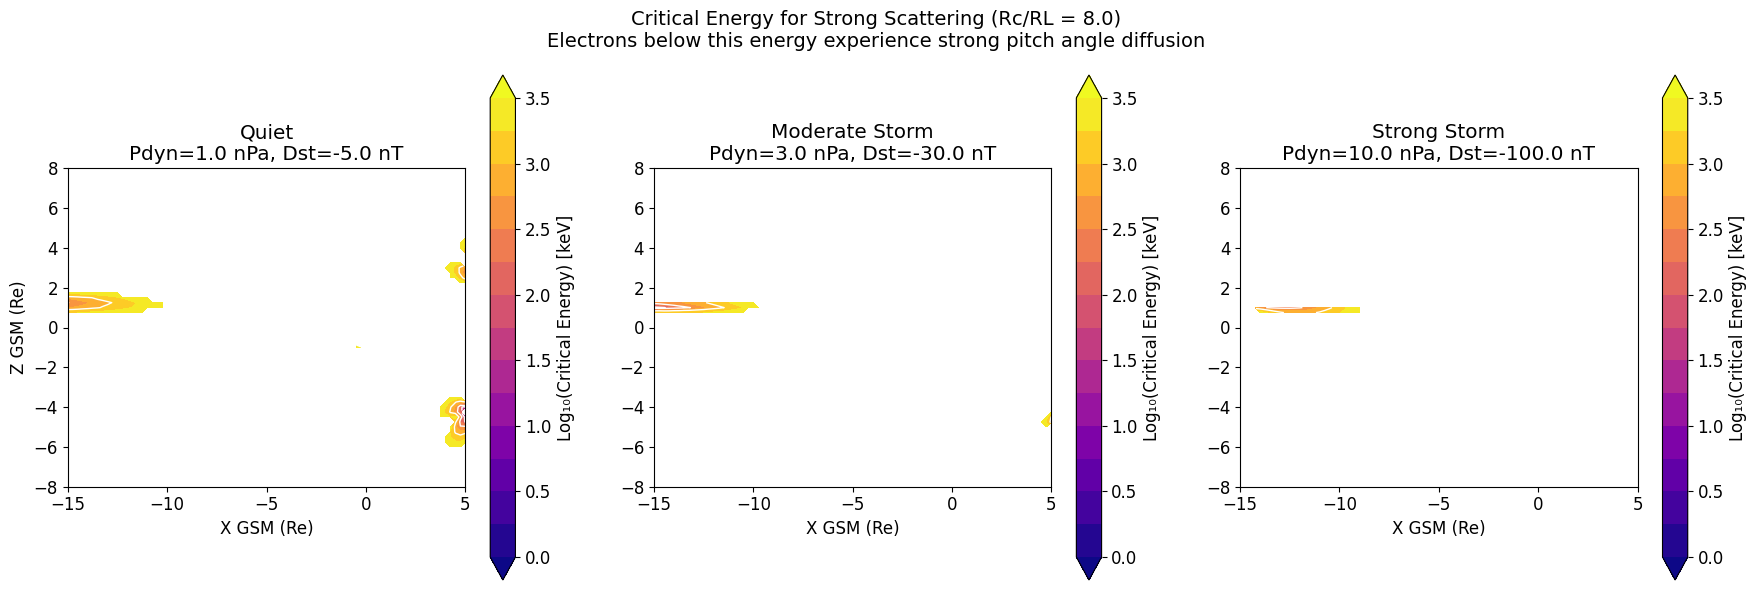

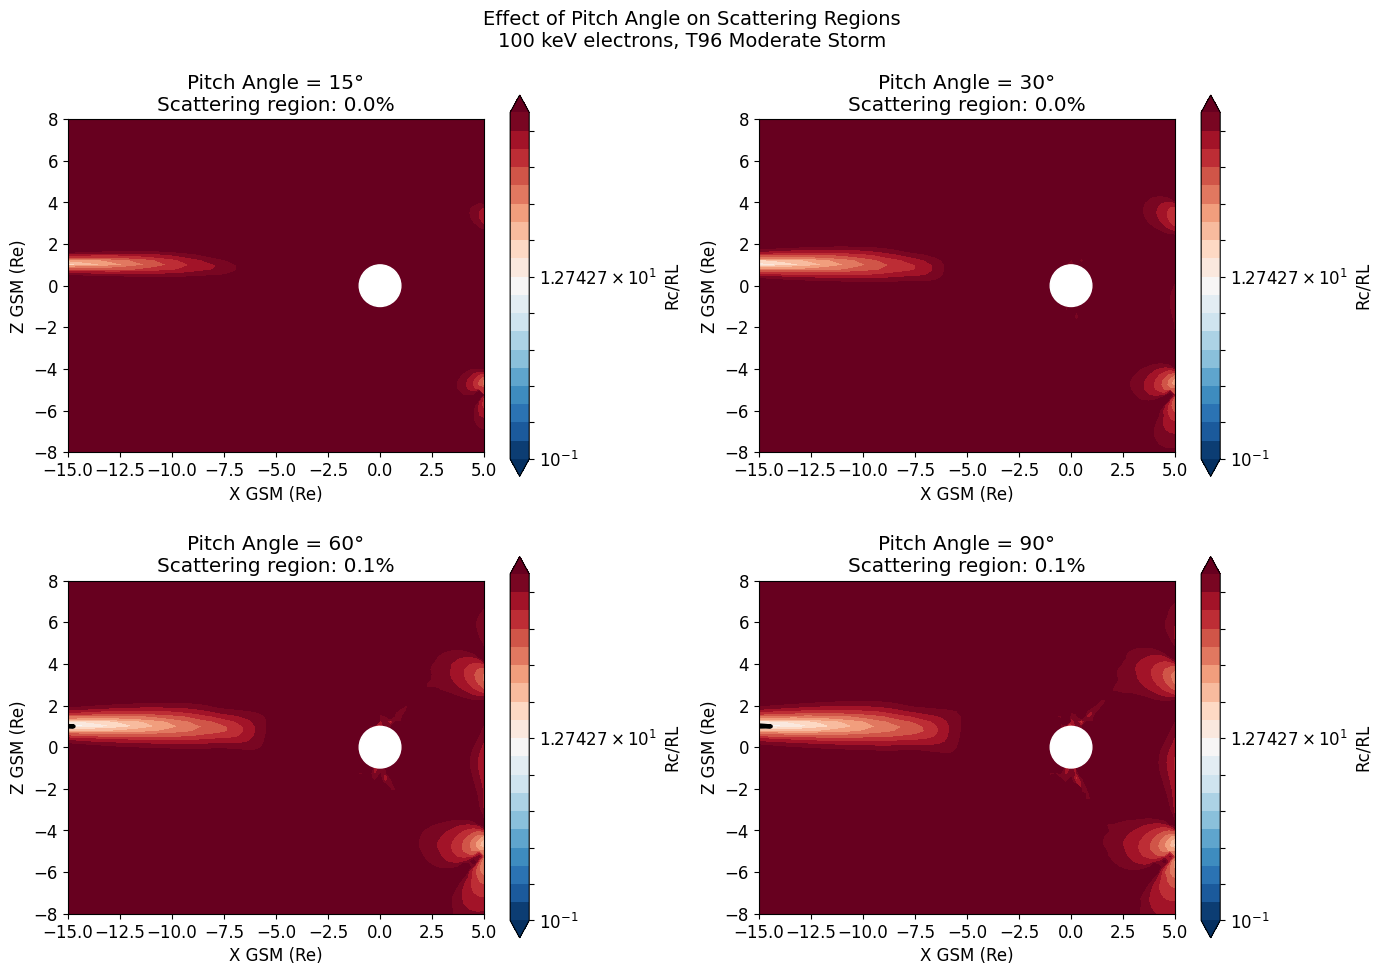

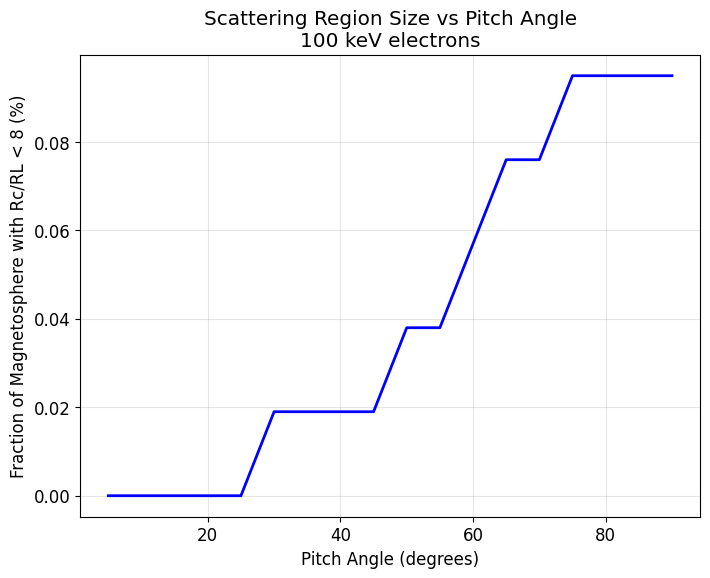

In [22]:
# Calculate the critical energy where Rc/RL = 8
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

conditions = [
    ("Quiet", parmod_quiet),
    ("Moderate Storm", parmod_moderate),
    ("Strong Storm", parmod_storm)
]

# Create grid for analysis
x_grid = np.linspace(-15, 5, 81)
z_grid = np.linspace(-8, 8, 65)
X, Z = np.meshgrid(x_grid, z_grid)
Y = np.zeros_like(X)

x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Energy range for searching
E_search = np.logspace(0, 3.5, 200)  # 1 keV to ~3 MeV

for idx, (label, parmod) in enumerate(conditions):
    ax = axes[idx]
    
    # Calculate fields
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod, ps, 
                                             x_flat, y_flat, z_flat)
    Rc_m = Rc_Re * Re
    
    # Find critical energy for each point
    critical_energy = np.zeros_like(x_flat)
    
    for i in range(len(x_flat)):
        if Rc_Re[i] > 1e9:  # No curvature
            critical_energy[i] = np.nan
            continue
            
        # Calculate ratio for all energies
        RL_m = calculate_larmor_radius(E_search, B_nT[i], pitch_angle_deg=90)
        ratios = Rc_m[i] / RL_m
        
        # Find where ratio crosses 8
        idx_cross = np.where(ratios < CRITICAL_RATIO)[0]
        if len(idx_cross) > 0:
            critical_energy[i] = E_search[idx_cross[0]]
        else:
            critical_energy[i] = np.nan  # Always adiabatic
    
    critical_energy_grid = critical_energy.reshape(X.shape)
    
    # Plot with log scale
    im = ax.contourf(X, Z, np.log10(critical_energy_grid), 
                     levels=np.linspace(0, 3.5, 15),
                     cmap='plasma', extend='both')
    
    # Add contours
    cs = ax.contour(X, Z, critical_energy_grid, 
                    levels=[10, 30, 100, 300, 1000],
                    colors='white', linewidths=1)
    ax.clabel(cs, inline=True, fontsize=10, fmt='%d keV')
    
    ax.set_title(f'{label}\nPdyn={parmod[0]} nPa, Dst={parmod[1]} nT')
    ax.set_xlabel('X GSM (Re)')
    if idx == 0:
        ax.set_ylabel('Z GSM (Re)')
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-15, 5)
    ax.set_ylim(-8, 8)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Log₁₀(Critical Energy) [keV]')
    
    # Calculate statistics
    valid = ~np.isnan(critical_energy)
    if np.sum(valid) > 0:
        mean_crit = np.mean(critical_energy[valid])
        median_crit = np.median(critical_energy[valid])
    
    print(f"{label}:")    
    print(f"  Mean critical energy: {mean_crit:.1f} keV")
    print(f"  Median critical energy: {median_crit:.1f} keV")

plt.suptitle(f'Critical Energy for Strong Scattering (Rc/RL = {CRITICAL_RATIO})\n' +
             'Electrons below this energy experience strong pitch angle diffusion',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Now analyze pitch angle effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fixed energy
energy_fixed = 100  # keV
pitch_angles = [15, 30, 60, 90]  # degrees

for idx, pa in enumerate(pitch_angles):
    ax = axes.flatten()[idx]
    
    # Calculate for moderate storm conditions
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                             x_flat, y_flat, z_flat)
    Rc_m = Rc_Re * Re
    
    # Calculate Larmor radius for this pitch angle
    RL_m = calculate_larmor_radius(energy_fixed, B_nT, pitch_angle_deg=pa)
    ratio = Rc_m / RL_m
    
    # Clean up ratio values - cap at reasonable maximum
    ratio = np.where(ratio > 1e6, 1e6, ratio)
    ratio = np.where(ratio < 1e-2, 1e-2, ratio)
    ratio_grid = ratio.reshape(X.shape)
    
    # Calculate scattering fraction
    scatter_frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
    
    # Plot with explicit vmin/vmax
    levels = np.logspace(-1, 3, 20)  # 0.1 to 1000
    im = ax.contourf(X, Z, ratio_grid,
                     levels=levels,
                     cmap='RdBu_r', extend='both', norm=LogNorm(vmin=0.1, vmax=1000))
    
    # Add critical contour
    cs = ax.contour(X, Z, ratio_grid, levels=[CRITICAL_RATIO], 
                    colors='black', linewidths=3)
    ax.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')
    
    # Add other contours
    ax.contour(X, Z, ratio_grid, levels=[1, 2, 4], 
               colors='gray', linewidths=1, alpha=0.5)
    
    ax.set_title(f'Pitch Angle = {pa}°\nScattering region: {scatter_frac:.1f}%')
    ax.set_xlabel('X GSM (Re)')
    ax.set_ylabel('Z GSM (Re)')
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-15, 5)
    ax.set_ylim(-8, 8)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Rc/RL')

plt.suptitle(f'Effect of Pitch Angle on Scattering Regions\n' +
             f'{energy_fixed} keV electrons, T96 Moderate Storm',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Summary plot: scattering fraction vs pitch angle
pa_range = np.linspace(5, 90, 18)
scatter_fracs = []

for pa in pa_range:
    RL_m = calculate_larmor_radius(energy_fixed, B_nT, pitch_angle_deg=pa)
    ratio = Rc_m / RL_m
    # Clean up ratio
    ratio = np.where(ratio > 1e6, 1e6, ratio)
    scatter_frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
    scatter_fracs.append(scatter_frac)

plt.figure(figsize=(8, 6))
plt.plot(pa_range, scatter_fracs, 'b-', linewidth=2)
plt.xlabel('Pitch Angle (degrees)')
plt.ylabel('Fraction of Magnetosphere with Rc/RL < 8 (%)')
plt.title(f'Scattering Region Size vs Pitch Angle\n{energy_fixed} keV electrons')
plt.grid(True, alpha=0.3)
plt.show()
plt.close(fig)

## Analysis 4: Time Evolution During a Storm

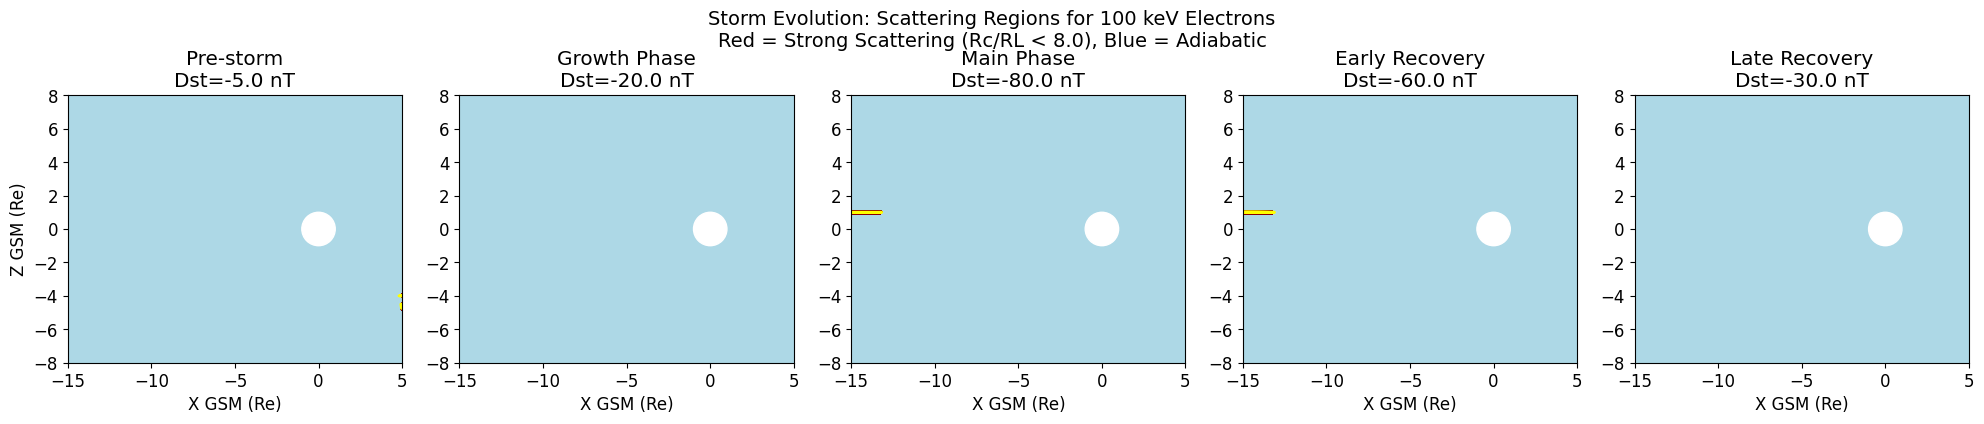

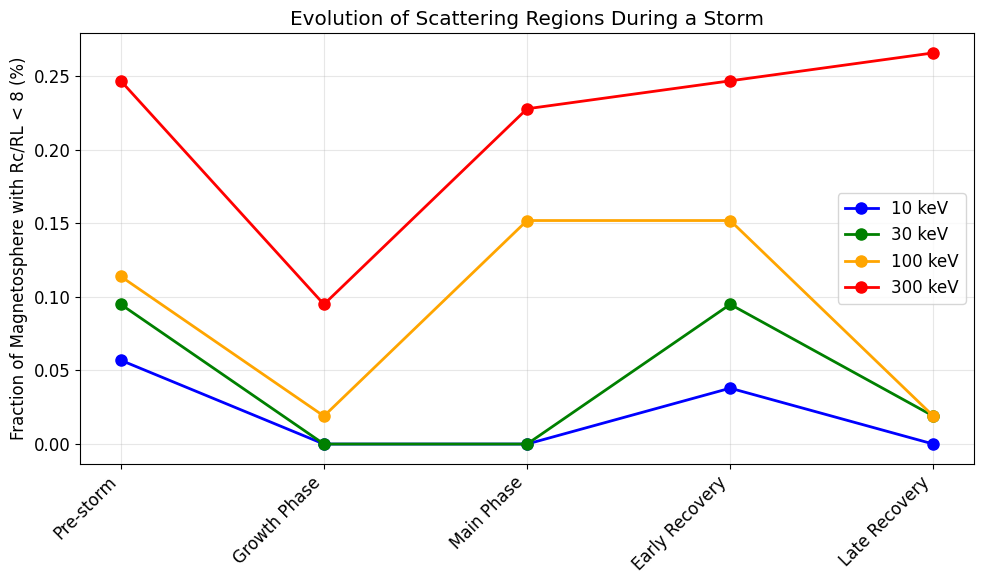

Storm Evolution Summary:
Pre-storm:
   10 keV:   0.1% scattering
   30 keV:   0.1% scattering
  100 keV:   0.1% scattering
  300 keV:   0.2% scattering
Growth Phase:
   10 keV:   0.0% scattering
   30 keV:   0.0% scattering
  100 keV:   0.0% scattering
  300 keV:   0.1% scattering
Main Phase:
   10 keV:   0.0% scattering
   30 keV:   0.0% scattering
  100 keV:   0.2% scattering
  300 keV:   0.2% scattering
Early Recovery:
   10 keV:   0.0% scattering
   30 keV:   0.1% scattering
  100 keV:   0.2% scattering
  300 keV:   0.2% scattering
Late Recovery:
   10 keV:   0.0% scattering
   30 keV:   0.0% scattering
  100 keV:   0.0% scattering
  300 keV:   0.3% scattering


In [23]:
# Simulate storm evolution
# Storm phases: quiet -> growth -> main -> recovery
storm_phases = [
    ("Pre-storm", [1.0, -5.0, 0.0, 2.0]),
    ("Growth Phase", [3.0, -20.0, 2.0, -5.0]),
    ("Main Phase", [8.0, -80.0, 5.0, -15.0]),
    ("Early Recovery", [4.0, -60.0, 3.0, -8.0]),
    ("Late Recovery", [2.0, -30.0, 1.0, -3.0])
]

# Test for multiple energies
test_energies = [10, 30, 100, 300]  # keV

# Calculate scattering regions for each phase
scatter_stats = {energy: [] for energy in test_energies}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (phase, params) in enumerate(storm_phases):
    ax = axes[idx]
    full_params = params + [0, 0, 0, 0, 0, 0]
    
    # Calculate fields
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, full_params, ps, 
                                             x_flat, y_flat, z_flat)
    Rc_m = Rc_Re * Re
    
    # Show for 100 keV electrons
    energy_show = 100
    RL_m = calculate_larmor_radius(energy_show, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    ratio_grid = ratio.reshape(X.shape)
    
    # Binary map
    scatter_map = (ratio_grid < CRITICAL_RATIO).astype(float)
    
    # Plot
    im = ax.contourf(X, Z, scatter_map, levels=[0, 0.5, 1],
                     colors=['lightblue', 'darkred'])
    
    # Add critical contour
    cs = ax.contour(X, Z, ratio_grid, levels=[CRITICAL_RATIO], 
                    colors='yellow', linewidths=2)
    
    ax.set_title(f'{phase}\nDst={params[1]} nT')
    ax.set_xlabel('X GSM (Re)')
    if idx == 0:
        ax.set_ylabel('Z GSM (Re)')
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-15, 5)
    ax.set_ylim(-8, 8)
    
    # Calculate statistics for all energies
    for energy in test_energies:
        RL_m = calculate_larmor_radius(energy, B_nT, pitch_angle_deg=90)
        ratio = Rc_m / RL_m
        scatter_frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
        scatter_stats[energy].append(scatter_frac)

plt.suptitle(f'Storm Evolution: Scattering Regions for {energy_show} keV Electrons\n' +
             f'Red = Strong Scattering (Rc/RL < {CRITICAL_RATIO}), Blue = Adiabatic',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Plot time evolution
fig, ax = plt.subplots(figsize=(10, 6))
phase_names = [phase[0] for phase in storm_phases]
x_pos = np.arange(len(phase_names))

colors = ['blue', 'green', 'orange', 'red']
for energy, color in zip(test_energies, colors):
    ax.plot(x_pos, scatter_stats[energy], 'o-', color=color, 
            linewidth=2, markersize=8, label=f'{energy} keV')

ax.set_xticks(x_pos)
ax.set_xticklabels(phase_names, rotation=45, ha='right')
ax.set_ylabel('Fraction of Magnetosphere with Rc/RL < 8 (%)')
ax.set_title('Evolution of Scattering Regions During a Storm')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close(fig)

# Print storm evolution summary
print("Storm Evolution Summary:")
print("=" * 60)
for i, phase in enumerate(phase_names):
    print(f"{phase}:")
    for energy in test_energies:
        print(f"  {energy:3d} keV: {scatter_stats[energy][i]:5.1f}% scattering")

## Analysis 5: Precipitation Patterns

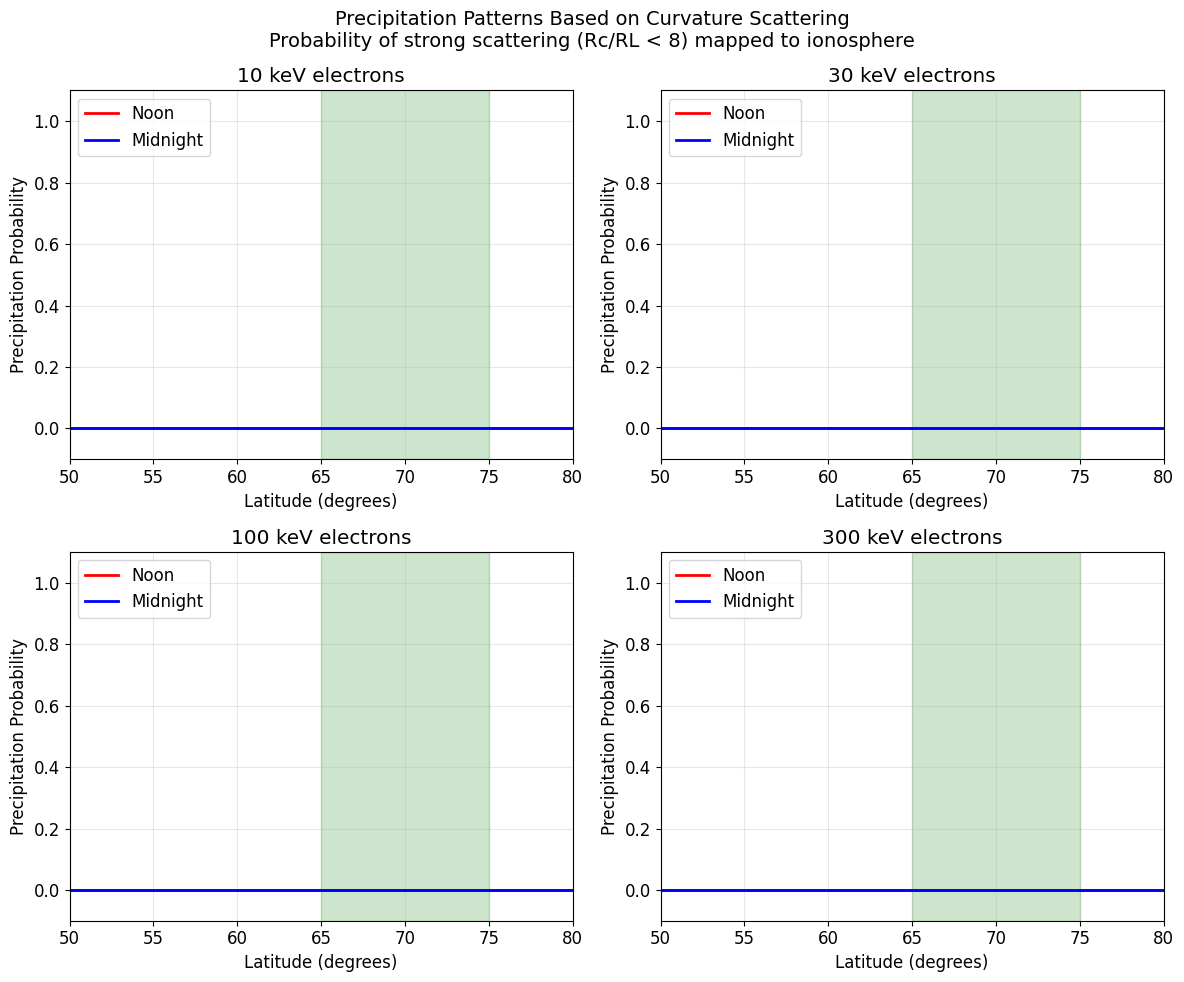

Precipitation Analysis Summary:
Strong curvature scattering leads to precipitation in:
- Lower latitudes for higher energy electrons
- Midnight sector shows broader precipitation region
- Storm-time expansion of precipitation zone


In [24]:
# Analyze where particles are most likely to precipitate
# Focus on the ionospheric footpoints of scattering regions

# Create a finer grid near Earth
r_iono = 1.1  # Ionospheric altitude mapping
theta = np.linspace(0, np.pi, 91)  # Colatitude
phi = np.array([0, np.pi])  # Noon and midnight

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

energies_precip = [10, 30, 100, 300]  # keV

for idx, energy in enumerate(energies_precip):
    ax = axes[idx]
    
    # Map from ionosphere to magnetosphere along field lines
    # This is simplified - in reality would trace field lines
    lat_grid = 90 - np.degrees(theta)
    L_shell = r_iono / np.cos(theta)**2  # Dipole approximation
    
    # Sample along field lines at equator
    x_eq = L_shell
    y_eq = np.zeros_like(L_shell)
    z_eq = np.zeros_like(L_shell)
    
    # Limit to reasonable L-shells
    mask = (L_shell > 2) & (L_shell < 10)
    
    precip_prob_noon = np.zeros_like(lat_grid)
    precip_prob_midnight = np.zeros_like(lat_grid)
    
    # Calculate for noon meridian
    Rc_Re_noon, B_nT_noon = calculate_curvature_radius(
        t96_vectorized, parmod_moderate, ps, 
        x_eq[mask], y_eq[mask], z_eq[mask]
    )
    
    RL_m = calculate_larmor_radius(energy, B_nT_noon, pitch_angle_deg=45)
    ratio_noon = Rc_Re_noon * Re / RL_m
    precip_prob_noon[mask] = (ratio_noon < CRITICAL_RATIO).astype(float)
    
    # Calculate for midnight meridian
    Rc_Re_mid, B_nT_mid = calculate_curvature_radius(
        t96_vectorized, parmod_moderate, ps, 
        -x_eq[mask], y_eq[mask], z_eq[mask]
    )
    
    RL_m = calculate_larmor_radius(energy, B_nT_mid, pitch_angle_deg=45)
    ratio_mid = Rc_Re_mid * Re / RL_m
    precip_prob_midnight[mask] = (ratio_mid < CRITICAL_RATIO).astype(float)
    
    # Plot latitude profiles
    ax.plot(lat_grid, precip_prob_noon, 'r-', linewidth=2, label='Noon')
    ax.plot(lat_grid, precip_prob_midnight, 'b-', linewidth=2, label='Midnight')
    
    ax.set_xlabel('Latitude (degrees)')
    ax.set_ylabel('Precipitation Probability')
    ax.set_title(f'{energy} keV electrons')
    ax.set_xlim(50, 80)
    ax.set_ylim(-0.1, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add auroral zone reference
    ax.axvspan(65, 75, alpha=0.2, color='green', label='Typical Auroral Zone')

plt.suptitle('Precipitation Patterns Based on Curvature Scattering\n'
             'Probability of strong scattering (Rc/RL < 8) mapped to ionosphere',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

print("Precipitation Analysis Summary:")
print("=" * 50)
print("Strong curvature scattering leads to precipitation in:")
print("- Lower latitudes for higher energy electrons")
print("- Midnight sector shows broader precipitation region")
print("- Storm-time expansion of precipitation zone")

## Analysis 6: Model Comparison

/home/skipjack/Documents/geopack-vectorize/geopack/vectorized/t01_vectorized.py:623: RuntimeWarning: invalid value encountered in divide
  cphi = np.where(rho != 0, y / rho, 1.0)
/home/skipjack/Documents/geopack-vectorize/geopack/vectorized/t01_vectorized.py:624: RuntimeWarning: invalid value encountered in divide
  sphi = np.where(rho != 0, z / rho, 0.0)
/home/skipjack/Documents/geopack-vectorize/geopack/vectorized/t01_vectorized.py:1028: RuntimeWarning: invalid value encountered in divide
  +beta*ps*r1rh**(eps-1)*rho/(rh*rsc*(1+r1rh**eps)**(1/eps+1))
/home/skipjack/Documents/geopack-vectorize/geopack/vectorized/t01_vectorized.py:1029: RuntimeWarning: invalid value encountered in divide
  dphisdy= beta*ps*r1rh**(eps-1)*ysc/(rh*rsc*(1+r1rh**eps)**(1/eps+1))
/home/skipjack/Documents/geopack-vectorize/geopack/vectorized/t01_vectorized.py:1111: RuntimeWarning: invalid value encountered in divide
  s = np.where(r != 0, rho / r, 0.0)
/home/skipjack/Documents/geopack-vectorize/geopack/vector

/tmp/ipykernel_16375/3770515726.py:21: RuntimeWarning: divide by zero encountered in divide
  Rc = np.where(kappa > 1e-10, 1.0 / kappa, 1e10)


/tmp/ipykernel_16375/3770515726.py:21: RuntimeWarning: divide by zero encountered in divide
  Rc = np.where(kappa > 1e-10, 1.0 / kappa, 1e10)


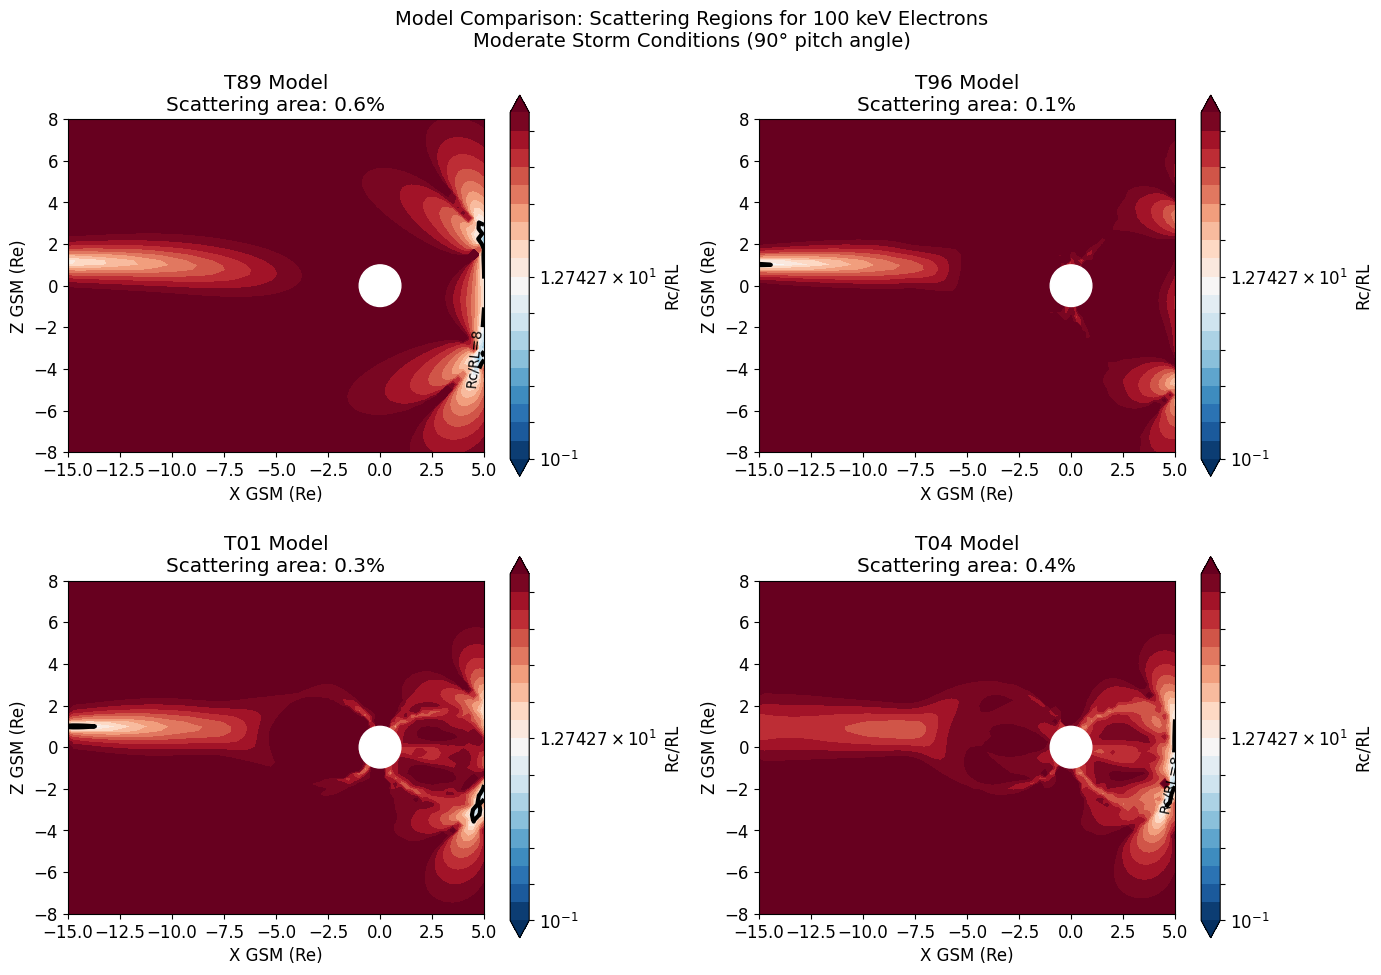

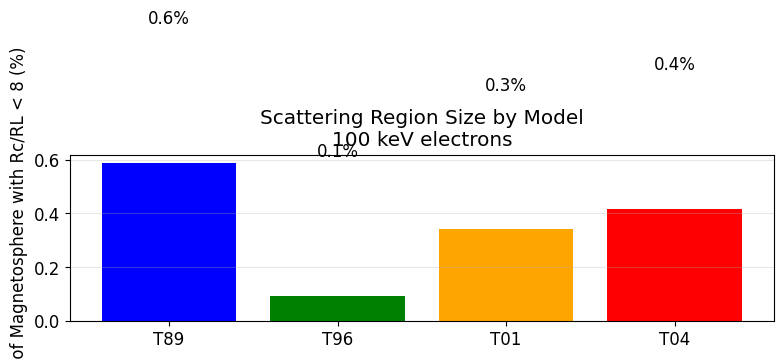

In [25]:
# Compare scattering regions across different models
models = [
    ('T89', t89_vectorized, 3),  # Kp = 3
    ('T96', t96_vectorized, parmod_moderate),
    ('T01', t01_vectorized, parmod_moderate + [0.5, 0.5]),
    ('T04', t04_vectorized, parmod_moderate + [0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

energy_compare = 100  # keV

scatter_areas = {}

for idx, (model_name, model_func, params) in enumerate(models):
    ax = axes[idx]
    
    # Calculate fields
    Rc_Re, B_nT = calculate_curvature_radius(model_func, params, ps, 
                                             x_flat, y_flat, z_flat)
    Rc_m = Rc_Re * Re
    
    # Calculate ratio
    RL_m = calculate_larmor_radius(energy_compare, B_nT, pitch_angle_deg=90)
    ratio = Rc_m / RL_m
    
    # Clean up ratio values
    ratio = np.where(ratio > 1e6, 1e6, ratio)
    ratio = np.where(ratio < 1e-2, 1e-2, ratio)
    ratio_grid = ratio.reshape(X.shape)
    
    # Calculate scattering area
    scatter_frac = np.sum(ratio < CRITICAL_RATIO) / len(ratio) * 100
    scatter_areas[model_name] = scatter_frac
    
    # Plot with explicit levels and vmin/vmax
    levels = np.logspace(-1, 3, 20)  # 0.1 to 1000
    im = ax.contourf(X, Z, ratio_grid,
                     levels=levels,
                     cmap='RdBu_r', extend='both', norm=LogNorm(vmin=0.1, vmax=1000))
    
    # Add critical contour
    cs = ax.contour(X, Z, ratio_grid, levels=[CRITICAL_RATIO], 
                    colors='black', linewidths=3)
    ax.clabel(cs, inline=True, fontsize=10, fmt='Rc/RL=8')
    
    ax.set_title(f'{model_name} Model\nScattering area: {scatter_frac:.1f}%')
    ax.set_xlabel('X GSM (Re)')
    ax.set_ylabel('Z GSM (Re)')
    
    # Add Earth
    earth = plt.Circle((0, 0), 1, color='white', zorder=10)
    ax.add_patch(earth)
    ax.set_aspect('equal')
    ax.set_xlim(-15, 5)
    ax.set_ylim(-8, 8)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Rc/RL')

plt.suptitle(f'Model Comparison: Scattering Regions for {energy_compare} keV Electrons\n' +
             f'Moderate Storm Conditions (90° pitch angle)',
             fontsize=14)
plt.tight_layout()
plt.show()
plt.close(fig)

# Summary bar chart
fig, ax = plt.subplots(figsize=(8, 6))
model_names = list(scatter_areas.keys())
scatter_values = list(scatter_areas.values())

bars = ax.bar(model_names, scatter_values, color=['blue', 'green', 'orange', 'red'])
ax.set_ylabel('Fraction of Magnetosphere with Rc/RL < 8 (%)')
ax.set_title(f'Scattering Region Size by Model\n{energy_compare} keV electrons')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, scatter_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()
plt.close(fig)

## Summary and Physical Implications

/tmp/ipykernel_16375/628069842.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


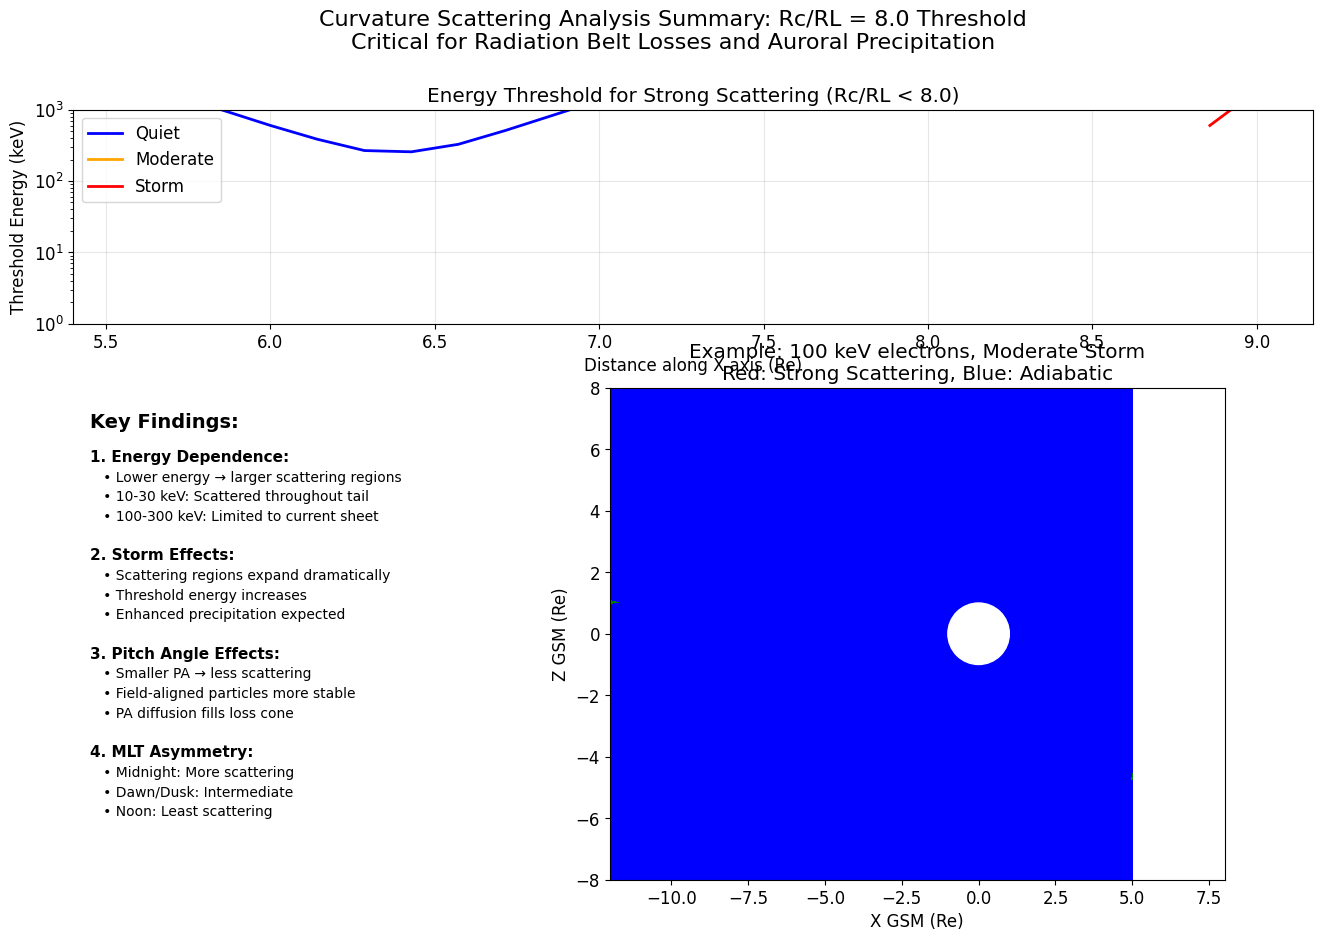

Physical Implications of Rc/RL < 8:
• Strong violation of first adiabatic invariant
• Rapid pitch angle diffusion fills loss cone
• Enhanced particle precipitation to atmosphere
• Important for:
  - Radiation belt electron losses
  - Diffuse aurora generation
  - Ionospheric conductivity enhancement
  - Atmospheric chemistry changes
Storm-time expansion of Rc/RL < 8 regions drives:
  - Rapid radiation belt depletions
  - Expanded auroral zones
  - Enhanced energy deposition to upper atmosphere


In [26]:
# Create summary figure
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Panel 1: Energy threshold along radial distance
ax1 = fig.add_subplot(gs[0, :])
r_test = np.linspace(3, 10, 50)
x_test = r_test
y_test = np.zeros_like(r_test)
z_test = np.zeros_like(r_test)

for condition, params, color in [("Quiet", parmod_quiet, 'blue'),
                                  ("Moderate", parmod_moderate, 'orange'),
                                  ("Storm", parmod_storm, 'red')]:
    Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, params, ps, 
                                             x_test, y_test, z_test)
    Rc_m = Rc_Re * Re
    
    # Find threshold energy
    E_threshold = np.zeros_like(r_test)
    for i in range(len(r_test)):
        RL_m_test = calculate_larmor_radius(E_search, B_nT[i], pitch_angle_deg=90)
        ratio_test = Rc_m[i] / RL_m_test
        idx = np.where(ratio_test < CRITICAL_RATIO)[0]
        if len(idx) > 0:
            E_threshold[i] = E_search[idx[0]]
        else:
            E_threshold[i] = np.nan
    
    mask = ~np.isnan(E_threshold)
    ax1.semilogy(r_test[mask], E_threshold[mask], '-', color=color, 
                 linewidth=2, label=condition)

ax1.set_xlabel('Distance along X-axis (Re)')
ax1.set_ylabel('Threshold Energy (keV)')
ax1.set_title(f'Energy Threshold for Strong Scattering (Rc/RL < {CRITICAL_RATIO})')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(1, 1000)

# Panel 2: Key findings text
ax2 = fig.add_subplot(gs[1:, 0])
ax2.text(0.05, 0.95, 'Key Findings:', fontsize=14, weight='bold',
         transform=ax2.transAxes, verticalalignment='top')

findings_text = [
    '1. Energy Dependence:',
    '   • Lower energy → larger scattering regions',
    '   • 10-30 keV: Scattered throughout tail',
    '   • 100-300 keV: Limited to current sheet',
    '',
    '2. Storm Effects:',
    '   • Scattering regions expand dramatically',
    '   • Threshold energy increases',
    '   • Enhanced precipitation expected',
    '',
    '3. Pitch Angle Effects:',
    '   • Smaller PA → less scattering',
    '   • Field-aligned particles more stable',
    '   • PA diffusion fills loss cone',
    '',
    '4. MLT Asymmetry:',
    '   • Midnight: More scattering',
    '   • Dawn/Dusk: Intermediate',
    '   • Noon: Least scattering'
]

y_pos = 0.85
for line in findings_text:
    if line and line[0].isdigit():
        ax2.text(0.05, y_pos, line, transform=ax2.transAxes, 
                 fontsize=11, weight='bold')
    else:
        ax2.text(0.05, y_pos, line, transform=ax2.transAxes, fontsize=10)
    y_pos -= 0.04

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# Panel 3: Scattering region visualization
ax3 = fig.add_subplot(gs[1:, 1:])

# Show moderate storm, 100 keV
Rc_Re, B_nT = calculate_curvature_radius(t96_vectorized, parmod_moderate, ps, 
                                         x_flat, y_flat, z_flat)
Rc_m = Rc_Re * Re
RL_m = calculate_larmor_radius(100, B_nT, pitch_angle_deg=90)
ratio = Rc_m / RL_m
ratio_grid = ratio.reshape(X.shape)

im = ax3.contourf(X, Z, ratio_grid,
                  levels=[0, 1, 2, 4, 8, 16, 32, 64],
                  colors=['darkred', 'red', 'orange', 'yellow', 
                          'lightgreen', 'green', 'blue', 'darkblue'],
                  extend='both')

cs = ax3.contour(X, Z, ratio_grid, levels=[CRITICAL_RATIO], 
                 colors='black', linewidths=3)
ax3.clabel(cs, inline=True, fontsize=12, fmt='Rc/RL=8')

ax3.set_title('Example: 100 keV electrons, Moderate Storm\nRed: Strong Scattering, Blue: Adiabatic')
ax3.set_xlabel('X GSM (Re)')
ax3.set_ylabel('Z GSM (Re)')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax3.add_patch(earth)
ax3.set_aspect('equal')
ax3.set_xlim(-12, 8)
ax3.set_ylim(-8, 8)

plt.suptitle(f'Curvature Scattering Analysis Summary: Rc/RL = {CRITICAL_RATIO} Threshold\n' +
             'Critical for Radiation Belt Losses and Auroral Precipitation',
             fontsize=16)
plt.tight_layout()
plt.show()
plt.close(fig)

print("Physical Implications of Rc/RL < 8:")
print("=" * 60)
print("• Strong violation of first adiabatic invariant")
print("• Rapid pitch angle diffusion fills loss cone")
print("• Enhanced particle precipitation to atmosphere")
print("• Important for:")
print("  - Radiation belt electron losses")
print("  - Diffuse aurora generation")
print("  - Ionospheric conductivity enhancement")
print("  - Atmospheric chemistry changes")
print("Storm-time expansion of Rc/RL < 8 regions drives:")
print("  - Rapid radiation belt depletions")
print("  - Expanded auroral zones")
print("  - Enhanced energy deposition to upper atmosphere")